# This code constructs an absorption model in SITELLE filters (SN1, SN2, and SN3).
## The code is inspired by that of Étienne Massé.

# Thanks to: Mykola Posternak, Étienne Massé, Carmelle Robert 


In [114]:
import matplotlib.pyplot as plt
import numpy.typing as npt
import lineid_plot
import numpy as np
import warnings
import json    
import sys
import orb
import os
from IPython.utils import io

from matplotlib.ticker import AutoMinorLocator
from IPython.display import display_markdown
from scipy.interpolate import interp1d
from scipy import ndimage
from astropy.io import fits

from orcs_process_mod import SpectralCube
from abs_spectr import AbsSpectrum
from fit_abs_ppxf import PpxfFit
import util

from skimage.transform import AffineTransform, warp

warnings.filterwarnings('ignore')

# Pour avoir le font de LaTeX dans les légendes et labels (r'$$' pour mettre du font de math)
plt.rcParams['text.usetex'] = True
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['font.family'] = 'serif'
plt.rcParams["savefig.dpi"] = 100
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 18

## **1. Data and information**

In [115]:
# Dictionary which contains paths to data (cubes/maps)

jsonfile = '../../data.json'
data_paths_dict = json.load(open(jsonfile))


In [121]:
xi3,xf3,yi3,yf3 = data_paths_dict['Image portion xi,xf,yi,yf'] 
print('Image portion xi,xf,yi,yf SN3: ', xi3,xf3,yi3,yf3)

print()
### SN3
cube_sn3          = SpectralCube(data_paths_dict['cube_SN3'])
wcs3              = cube_sn3.get_wcs()
npix_x_sn3, npix_y_sn3, nb_step_sn3 = cube_sn3.shape
deepframe_sn3,hdr3 = fits.getdata(data_paths_dict['deepframe_SN3'],header=True) 
display_markdown(f'### **SN3** \n'
    f'- Datacube size: {(npix_x_sn3, npix_y_sn3, nb_step_sn3)} \n'
    f'- Deepframe size: {deepframe_sn3.shape}', raw=True) 
flux_ha           = fits.getdata(data_paths_dict['flux_Halpha'])
cont3             = fits.getdata(data_paths_dict['continuum_SN3'])
cont3_err         = fits.getdata(data_paths_dict['continuum_SN3_err'])
cont3_snr         = cont3/cont3_err
noise_map_sn3     = np.copy(cont3_err) 
sky_sn3           = fits.getdata(data_paths_dict['skyspec_SN3'])
maskbg3           = fits.getdata('../../0-DATA-old+seb/Maskstar_all_SN3.fits') # has more things in the gal.
starvalue         = 0 
print('Starvalue: ',starvalue)

### SN2 
cube_sn2           = SpectralCube(data_paths_dict['cube_SN2'])
wcs2               = cube_sn2.get_wcs()
npix_x_sn2, npix_y_sn2, nb_step_sn2 = cube_sn2.shape
deepframe_sn2,hdr2 = fits.getdata(data_paths_dict['deepframe_SN2'],header=True)
display_markdown(f'### **SN2** \n'
    f'- Datacube size: {(npix_x_sn2, npix_y_sn2, nb_step_sn2)} \n'
    f'- Deepframe size: {deepframe_sn2.shape}', raw=True)
deepframe_sn2_ali  = fits.getdata(data_paths_dict['deepframe_SN2_alig'])
cont2              = fits.getdata(data_paths_dict['continuum_SN2'])
noise_map_sn2      = fits.getdata(data_paths_dict['continuum_SN2_err'])
sky_sn2            = fits.getdata(data_paths_dict['skyspec_SN2'])
print('SKY2:', sky_sn2.shape)
maskbg2            = fits.getdata('../../0-DATA-old+seb/Maskstar_all_SN2.fits') # has more things in the gal.

### SN1 
cube_sn1           = SpectralCube(data_paths_dict['cube_SN1'])
wcs1               = cube_sn1.get_wcs()
npix_x_sn1, npix_y_sn1, nb_step_sn1 = cube_sn1.shape
deepframe_sn1,hdr1 = fits.getdata(data_paths_dict['deepframe_SN1'],header=True)
display_markdown(f'### **SN1** \n'
    f'- Datacube size: {(npix_x_sn1, npix_y_sn1, nb_step_sn1)} \n'
    f'- Deepframe size: {deepframe_sn1.shape}', raw=True)
deepframe_sn1_ali  = fits.getdata(data_paths_dict['deepframe_SN1_alig'])
cont1              = fits.getdata(data_paths_dict['continuum_SN1'])
noise_map_sn1      = fits.getdata(data_paths_dict['continuum_SN1_err'])
sky_sn1            = fits.getdata(data_paths_dict['skyspec_SN1'])
maskbg1            = fits.getdata('../../0-DATA-old+seb/Maskstar_all_SN1.fits') # has more things in the gal.

###
print()
imavel_obs        = fits.getdata(data_paths_dict['velocity']) 
imavel_OHhelio    = fits.getdata(data_paths_dict['velocity_helio']) 
imadis            = fits.getdata(data_paths_dict['sigma'])
vel_mod_obs  = fits.getdata('../1-Velocity_CR_data/Velocity_model_obs_NGC_4490(3,10,45,5e-18)cone-Wonly-1080-960_61_113_565.fits')
#dynamical data for galaxy mask...
xc,yc,incd,pad = 1080,960,61,113
print('Dynamical data (centerSN3, i, PA): ',xc,yc, incd, pad)
r3,  d3   = wcs3.wcs_pix2world(xc,yc, 0)
xc2, yc2  = wcs2.wcs_world2pix(r3,d3, 0)
xc2, yc2  = np.round(xc2,0).astype(int),np.round(yc2,0).astype(int)
xc1,  yc1 = wcs1.wcs_world2pix(r3,d3, 0)
xc1,  yc1 = np.round(xc1,0).astype(int),np.round(yc1,0).astype(int)
print('Dynamical center SN2  : ',xc2,yc2)
print('Dynamical center SN1  : ',xc1,yc1)
gal_vel    = data_paths_dict['galaxy_velocity']        # km/s
print('Galaxy velocity (km/s): ', gal_vel)

print()
### Flux calibration i.e. relative to Ha, Hb and OII (see Integrated_spectra routine) 
calfac = data_paths_dict['cal_factor123']
print('Flux calibration factors for SN1, SN2, and SN3: ', calfac)
cal_SN1, cal_SN2, cal_SN3 = calfac[0],calfac[1],calfac[2]
emi_lines = np.array(data_paths_dict['emission_lines_centroid']) # A
print(r'Main emission lines centroid (A):',emi_lines)
wlines    = 1.e8 / (emi_lines * (1+(gal_vel/3e5)))    # wavenumbers

print()
### Folder for new files (if already exits, files will be replaced)
Folder = '3-Absorption_results/'
if os.path.isdir(Folder) == False:
    os.mkdir(Folder)
    print('Folder created: ', Folder)
else:
    print('Folder exists already: ', Folder)
print()

unknown|INFO| Cube is level 3
unknown|INFO| shape: (2048, 2064, 842)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: True


Image portion xi,xf,yi,yf SN3:  300 1800 130 1900



### **SN3** 
- Datacube size: (2048, 2064, 842) 
- Deepframe size: (2064, 2048)

unknown|INFO| Cube is level 3
unknown|INFO| shape: (2048, 2064, 219)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: True


Starvalue:  0


...

unknown|INFO| Cube is level 3


SKY2: (219,)


unknown|INFO| shape: (2048, 2064, 172)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: True


### **SN1** 
- Datacube size: (2048, 2064, 172) 
- Deepframe size: (2064, 2048)


Dynamical data (centerSN3, i, PA):  1080 960 61 113
Dynamical center SN2  :  1080 959
Dynamical center SN1  :  1079 958
Galaxy velocity (km/s):  565

Flux calibration factors for SN1, SN2, and SN3:  [0.931, 1.1414, 0.9417]
Main emission lines centroid (A): [3727 4861 4959 5007 6562 6548 6583 6716 6731]

Folder exists already:  3-Absorption_results_Wfin/



In [117]:
def makeplot(log,code_col,imagein,imagevvi,x1,x2,y1,y2,a,vvimin,vvimax,cbarp):
    plt.rcParams['axes.linewidth'] = 2
    plt.tick_params(axis='both', direction='out', labelsize=20, length=6, width=2)
    plt.axis([x1,x2,y1,y2])
    if code_col == 0: col='rainbow'
    if code_col == 1: col='gray'
    if code_col == 2: col='Greys'
    if log == 1: 
        vvi=np.log10(imagevvi[y1:y2,x1:x2])
        plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if log != 1: 
        vvi=imagevvi[y1:y2,x1:x2]
        plt.imshow(imagein, cmap=col, origin='lower',alpha=a,vmin=vvimin,vmax=vvimax) 
    if cbarp == 1:
        cbar=plt.colorbar(pad=0.01)
        cbar.ax.tick_params(labelsize=20)
    plt.xlabel('X',size=25)
    plt.ylabel('Y',size=25)

def makecirc(xx,yy,r1,col):
    theta = np.linspace(0, 2*np.pi, 100)
    x,y = xx + (r1*np.cos(theta)), yy + (r1*np.sin(theta))
    plt.plot(x,y,color=col,lw=2)
    #x,y = xx + (r2*np.cos(theta)), yy + (r2*np.sin(theta))
    #plt.plot(x,y,'--',color=col,lw=1)
    #x,y = xx + (r3*np.cos(theta)), yy + (r3*np.sin(theta))
    #plt.plot(x,y,'--',color=col,lw=1)
    return

def makeellip(xx,yy,r1,incd,pad,col):
    theta = np.linspace(0, 2*np.pi, 100)
    theta = np.linspace(0, 2*np.pi, 200)
    a = r1             # grand axe
    inc  = np.radians(incd)
    pa  = np.radians(pad)
    b = r1*np.cos(inc)   # petit axe (si i = inclinaison du disque)
    # Ellipse avant rotation
    xe = a * np.cos(theta)
    ye = b * np.sin(theta) 
    # Rotation de l'ellipse
    x_rot = xe*np.cos(pa) - ye*np.sin(pa)
    y_rot = xe*np.sin(pa) + ye*np.cos(pa)
    # Translation au centre (xx, yy)
    x_final = xx + x_rot
    y_final = yy + y_rot
    x,y = xx + (r1*np.cos(theta)), yy + (r1*np.sin(theta))
    plt.plot(x_fin,y_fin,color=col,lw=1)
    return
    

# 0- Check center

In [118]:
print(vel_mod_obs[yc,xc])

649.7516818779068


Text(0.5, 1.0, 'Log(SN1 Deepimage)')

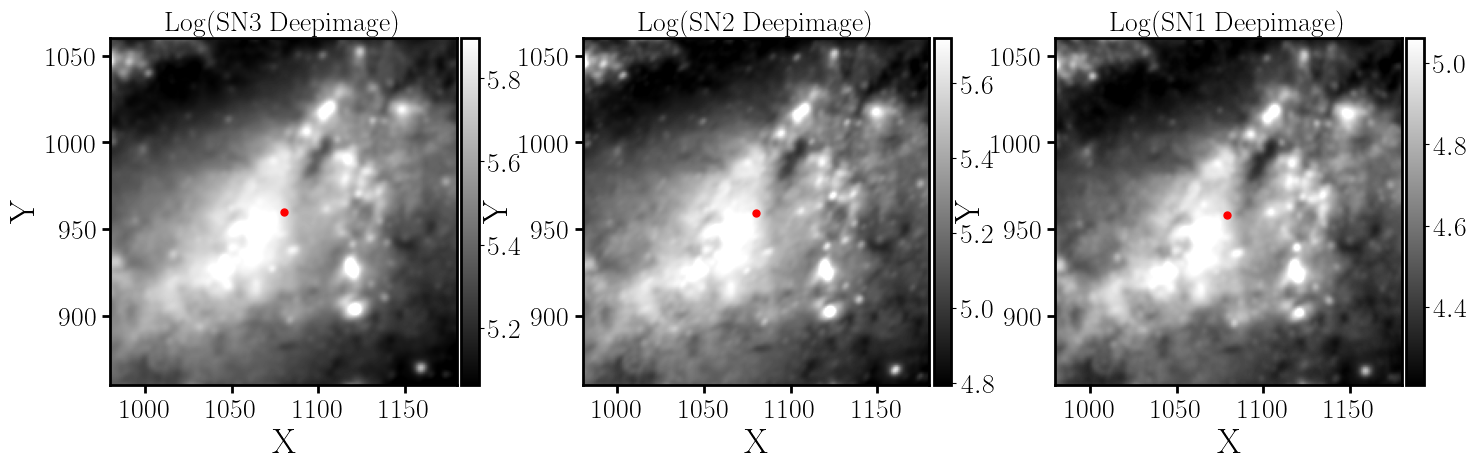

In [119]:
nyy, nxx, ip = 1,3, 0
fig = plt.figure(figsize=(6*nxx,4.5*nyy))
fig.subplots_adjust(hspace=0.2,wspace=0.05)


imasiz=100   
xmi,xma,ymi,yma = int(xc-imasiz),int(xc+imasiz),int(yc-imasiz),int(yc+imasiz)
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,1,deepframe_sn3,deepframe_sn3,xmi,xma,ymi,yma,1,1,98,1)
plt.plot(xc,yc,'ro',ms=5)
ax.set_title('Log(SN3 Deepimage)',size=20)
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,1,deepframe_sn2,deepframe_sn2,xmi,xma,ymi,yma,1,1,98,1)
plt.plot(xc2,yc2,'ro',ms=5)
ax.set_title('Log(SN2 Deepimage)',size=20)
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,1,deepframe_sn1,deepframe_sn1,xmi,xma,ymi,yma,1,1,98,1)
plt.plot(xc1,yc1,'ro',ms=5)
ax.set_title('Log(SN1 Deepimage)',size=20)


# 0- Test extracting one spectrm

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,



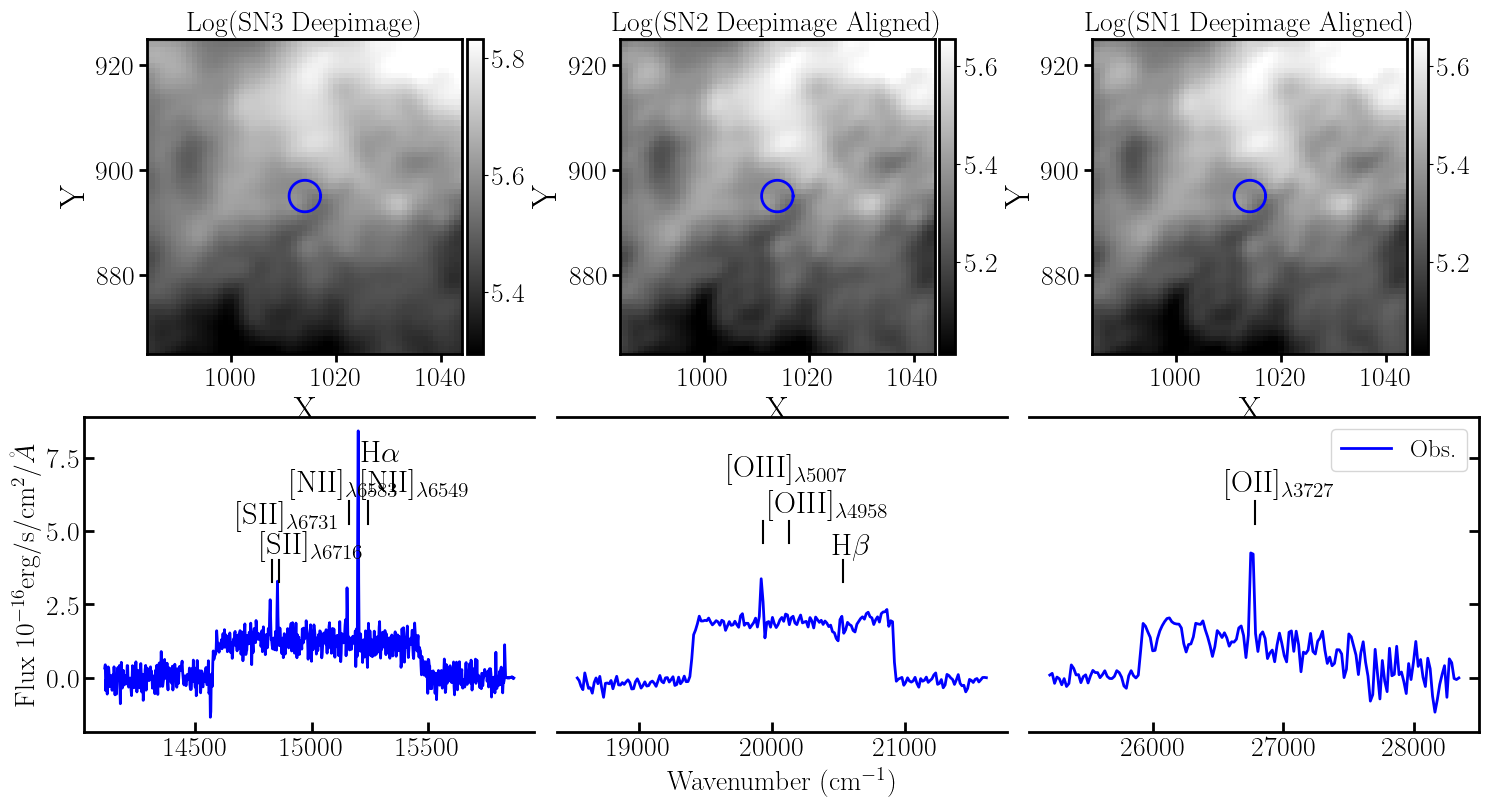

In [120]:

#x3, y3 = 1092,1172
#tit='E nuc.'
x3,y3  = 1014, 895 
tit='RHII'

r3, d3 = wcs3.wcs_pix2world(x3,y3, 0)
x2, y2 = wcs2.wcs_world2pix(r3,d3, 0)
x2, y2 = np.round(x2,0).astype(int),np.round(y2,0).astype(int)
x1, y1 = wcs1.wcs_world2pix(r3,d3, 0)
x1, y1 = np.round(x1,0).astype(int),np.round(y1,0).astype(int)

rr = 3 
line1 = ['[OII]3726']
line2 = ['Hbeta', '[OIII]5007', '[OIII]4959']
line3 = ['Halpha', '[NII]6583', '[NII]6548', '[SII]6716', '[SII]6731' ]

with io.capture_output() as captured:
    x0,y0 = x3,y3
    #range=cube3.params.filter_range #signal_range = range
    wave,spec,fit = cube_sn3.fit_lines_in_spectrum( x0,y0,rr, line3, fmodel='sincgauss', nofilter=False,
         pos_def = ['1'], pos_cov = imavel_obs[y0,x0], sigma_def = ['1'], sigma_cov = imadis[y0,x0],                                     
         mean_flux = False,
         poly_order = 1,
         subtract_spectrum = np.pi*((rr+0.5)**2)*sky_sn3 ) # pas certaine du nb de pixels si rr
    if fit.__class__.__name__ != 'OutputParams': 
         axis3,spec3,fit3 = wave.astype(float), spec.real.astype(float), 0*spec.real.astype(float)
    else: 
         axis3,spec3,fit3 = wave.astype(float), spec.real.astype(float), fit['fitted_vector'].astype(float)
    
    x0,y0 = x2,y2
    wave,spec,fit = cube_sn2.fit_lines_in_spectrum( x0,y0,rr,  line2, fmodel='sincgauss', nofilter=False,
         pos_def = ['1'], pos_cov = imavel_obs[y0,x0], sigma_def = ['1'], sigma_cov = imadis[y0,x0],                                     
         mean_flux = False,
         poly_order = 1,
         subtract_spectrum = np.pi*((rr+0.5)**2)*sky_sn2 )
    if fit.__class__.__name__ != 'OutputParams': 
         axis2,spec2,fit2 = wave.astype(float), spec.real.astype(float), 0*spec.real.astype(float)
    else: 
         axis2,spec2,fit2 = wave.astype(float), spec.real.astype(float), fit['fitted_vector'].astype(float)
    
    x0,y0 = x1,y1
    wave,spec,fit = cube_sn1.fit_lines_in_spectrum( x0,y0,rr, line1, fmodel='sincgauss', nofilter=False,
         pos_def = ['1'], pos_cov = imavel_obs[y0,x0], sigma_def = ['1'], sigma_cov = imadis[y0,x0],                                     
         mean_flux = False,
         poly_order = 1,
         subtract_spectrum = np.pi*((rr+0.5)**2)*sky_sn1 )
    if fit.__class__.__name__ != 'OutputParams': 
         axis1,spec1,fit1 = wave.astype(float), spec.real.astype(float), 0*spec.real.astype(float)
    else: 
         axis1,spec1,fit1 = wave.astype(float), spec.real.astype(float), fit['fitted_vector'].astype(float)

#### ajouter le fit...
%matplotlib inline
    

f       = np.nanmax(spec3).real
facplot = np.floor(np.log10(f)).astype(int)
maxf    = f*10**(-1*facplot)
delf    = maxf/10.
spec3p = spec3*10**(-1*facplot)
spec2p = spec2*10**(-1*facplot)
spec1p = spec1*10**(-1*facplot)
fit3p  =  fit3*10**(-1*facplot)
fit2p  =  fit2*10**(-1*facplot)
fit1p  =  fit1*10**(-1*facplot)
ymin,ymax  = np.nanmin(spec3p), np.nanmax(spec3p)
dely = (ymax-ymin)/20.
ymin, ymax = ymin-dely, ymax+dely
 
imasiz=30
rr
nyy, nxx, ip = 2,3, 0
fig = plt.figure(figsize=(6*nxx,4.5*nyy))
fig.subplots_adjust(hspace=0.2,wspace=0.05)
   
xmi,xma,ymi,yma = int(x3-imasiz),int(x3+imasiz),int(y3-imasiz),int(y3+imasiz)
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,1,deepframe_sn3,deepframe_sn3,xmi,xma,ymi,yma,1,1,98,1)
makecirc(x3,y3,rr,'blue')
ax.set_title('Log(SN3 Deepimage)',size=20)

siz=22
#xmi,xma,ymi,yma = int(x2-imasiz),int(x2+imasiz),int(y2-imasiz),int(y2+imasiz)
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,1,deepframe_sn2_ali,deepframe_sn2_ali,xmi,xma,ymi,yma,1,1,98,1)
makecirc(x3,y3,rr,'blue')
ax.set_title('Log(SN2 Deepimage Aligned)',size=20)

#xmi,xma,ymi,yma = int(x1-imasiz),int(x1+imasiz),int(y1-imasiz),int(y1+imasiz)
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,1,deepframe_sn2_ali,deepframe_sn2_ali,xmi,xma,ymi,yma,1,1,98,1)
makecirc(x3,y3,rr,'blue')
ax.set_title('Log(SN1 Deepimage Aligned)',size=20)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
ax.spines['right'].set_visible(False)
ax.yaxis.tick_left()
ax.tick_params(axis='both', direction='in',  left=True, top=False, right=False, bottom=True,labelleft=True, labeltop=False, labelright=False, labelbottom=True,labelsize=20, length=7, width=2)
#ax.set_xlim(14600,15400)
ax.set_ylim(ymin,ymax)
ax.plot(axis3,spec3p, '-',  color='blue',lw=2)
#ax.plot(axis3,fit3p, '-',  color='red',lw=2)
ax.set_ylabel(r'Flux 10$^{'+str(facplot)+'}$erg/s/cm$^{2}$/$\AA$', size=20)
ax.text(wlines[8]-150,maxf/1.6,r'[SII]$_{\lambda 6731}$',size=siz,weight='bold')
ax.plot([wlines[8],wlines[8]],[(maxf/2.05)-(delf/10),(maxf/2.05)-delf],'-',color='black')
ax.text(wlines[7]-80,maxf/2,r'[SII]$_{\lambda 6716}$',size=siz,weight='bold')
ax.plot([wlines[7],wlines[7]],[(maxf/2.05)-(delf/10),(maxf/2.05)-delf],'-',color='black')
ax.text(wlines[6]-250,maxf/1.33,r'[NII]$_{\lambda 6583}$',size=siz,weight='bold')
ax.plot([wlines[6],wlines[6]],[(maxf/1.38)-(delf/10),(maxf/1.38)-delf],'-',color='black')
ax.text(wlines[4]+3,maxf/1.14,r'H$\alpha$',size=siz,weight='bold')
ax.text(wlines[5]-25,maxf/1.33,r'[NII]$_{\lambda 6549}$',size=siz,weight='bold')
ax.plot([wlines[5],wlines[5]],[(maxf/1.38)-(delf/10),(maxf/1.38)-delf],'-',color='black')

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', direction='in',  left=False, top=False, right=False, bottom=True,labelleft=False, labeltop=False, labelright=False, labelbottom=True,labelsize=20, length=7, width=2)
#ax.set_xlim(19500,20900)
ax.set_ylim(ymin,ymax)
ax.plot(axis2,spec2p, '-',  color='blue',lw=2)
#ax.plot(axis2,fit2p, '-',  color='red',lw=2)
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)',size=20)
ax.text(wlines[3]-260,maxf/1.23,r'[OIII]$_{\lambda 5007}$',size=siz,weight='bold')
ax.plot([wlines[3],wlines[3]],[(maxf/1.55)-(delf/10),(maxf/1.55)-delf],'-',color='black')
ax.text(wlines[2]-150,maxf/1.5,r'[OIII]$_{\lambda 4958}$',size=siz,weight='bold')
ax.plot([wlines[2],wlines[2]],[(maxf/1.55)-(delf/10),(maxf/1.55)-delf],'-',color='black')
ax.text(wlines[1]-80,maxf/2.,r'H$\beta$',size=siz,weight='bold')
ax.plot([wlines[1],wlines[1]],[(maxf/2.05)-(delf/10),(maxf/2.05)-delf],'-',color='black')

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='both', direction='in',  left=False, top=False, right=True, bottom=True,labelleft=False, labeltop=False, labelright=False, labelbottom=True,labelsize=20, length=7, width=2)
#ax.set_xlim(26000,27500)
ax.set_ylim(ymin,ymax)
ax.plot(axis1,spec1p, '-',  color='blue',lw=2,label='Obs.')
#ax.plot(axis1,fit1p, '-',  color='red',lw=2,label='ORCS fit')
ax.text(wlines[0]-220,maxf/1.33,r'[OII]$_{\lambda 3727}$',size=siz,weight='bold')
ax.plot([wlines[0],wlines[0]],[(maxf/1.38)-(delf/10),(maxf/1.38)-delf],'-',color='black')
plt.legend()
plt.show()

#fig.savefig(Folder_fig+'/fig-Ima-Spec-Fit-'+tit+'.jpeg',bbox_inches = 'tight')
##plt.close(fig) 

# 1- Velocity maps

Correction SN2:  -5.833499999999958
Correction SN1:  156.09400000000005


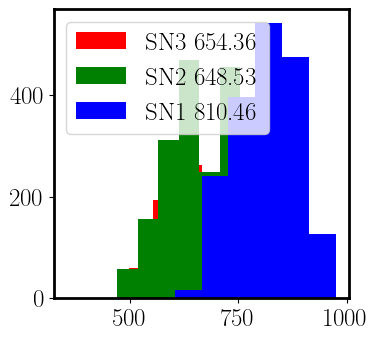

In [8]:
# here based on previous flux measurements for detected regions
# do not take into account the galaxy mask where the abs spectrum will be done but
# should if the mask is small (so do mask first)

from astropy.table import QTable

filename = '../../Step5-Integrated_spectra/1-Intspec_data_SP/Reg-Uncor.ascii'
table_flux  = QTable.read(filename,format='ascii')
vsn3 = table_flux['V_Halpha']
vsn2 = table_flux['V_Hbeta']
vsn1 = table_flux['V_[OII]3727']

vmedsn3= np.nanmedian(vsn3)
vmedsn2= np.nanmedian(vsn2)
vmedsn1= np.nanmedian(vsn1)


nyy, nxx, ip = 3,2, 0
fig = plt.figure(figsize=(4*nxx,4*nyy))
fig.subplots_adjust(hspace=0.1,wspace=0.1)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
#plt.xlim([3000,5000])
#plt.ylim([0,30])

plt.hist(vsn3,label='SN3'+' {:.2f}'.format(vmedsn3),color='red')
plt.hist(vsn2,label='SN2'+' {:.2f}'.format(vmedsn2),color='green')
plt.hist(vsn1,label='SN1'+' {:.2f}'.format(vmedsn1),color='blue')
plt.legend()

print('Correction SN2: ', vmedsn2-vmedsn3)
print('Correction SN1: ', vmedsn1-vmedsn3)

In [9]:
# Using the model obs = modelobs for SN3
# modelobs for SN2 = modelobs for SN3
# modelobs for SN1 = modelobs for SN3 + delta de 156
# modelobsSN2 and SN1 most be aligned for2 and for1

print('Med velo obs:',     np.nanmedian(    imavel_obs[yc-200:yc+200, xc-200:xc+200]))
print('Med velo cor:',     np.nanmedian(imavel_OHhelio[yc-200:yc+200, xc-200:xc+200]))
print('Med velo mod obs:', np.nanmedian(   vel_mod_obs[yc-200:yc+200, xc-200:xc+200]))

vel_mod3_obs = np.copy(vel_mod_obs)
vel_mod2_obs = np.copy(vel_mod_obs) -   6
vel_mod1_obs = np.copy(vel_mod_obs) + 156

print('Med vel_mod3_obs: ', np.nanmedian(vel_mod3_obs[yc-200:yc+200, xc-200:xc+200]))
print('Med vel_mod2_obs: ', np.nanmedian(vel_mod2_obs[yc-200:yc+200, xc-200:xc+200]))
print('Med vel_mod1_obs: ', np.nanmedian(vel_mod1_obs[yc-200:yc+200, xc-200:xc+200]))


print()
ohhelio_cor  = imavel_OHhelio - imavel_obs
print('Cor : ',ohhelio_cor[yc,xc])

### Velocity model for SN2 and SN1 (based on SN3) will be aligned for SN3

Med velo obs: 670.3114
Med velo cor: 581.6996
Med velo mod obs: 648.9054690884583
Med vel_mod3_obs:  648.9054690884583
Med vel_mod2_obs:  642.9054690884583
Med vel_mod1_obs:  804.9054690884583

Cor :  -88.355286
Med vel_mod3_helio:  560.6130795652193
Med vel_mod2_helio:  554.6130795652193
Med vel_mod1_helio:  716.6130795652193


In [10]:
#vel companion : 

velcom_sys = 483 #NED
vel_com = np.zeros(imavel_obs.shape) 
vel_com = vel_com + velcom_sys

vel_com3_obs = vel_com - ohhelio_cor 
vel_com2_obs = vel_com - 6 - ohhelio_cor 
vel_com1_obs = vel_com + 156 - ohhelio_cor 


# 2. Create aligned map

In [11]:
from skimage.transform import AffineTransform, warp

def ensure_little_endian(array):
   if array.dtype.byteorder == '>':  # Big-endian
       return array.byteswap().newbyteorder()
   elif array.dtype.byteorder == '=' and not array.dtype.isnative:
       # '=' indique la compatibilité avec le système, mais vérifions si c'est native
       return array.byteswap().newbyteorder()
   else:
       return array
       
def aligmapnotinv(solution,hdr,filein,filejason,fileout): 
    filetoalig = np.copy(filein)
    filetoalig = ensure_little_endian(filetoalig)
    filealig   = warp(filetoalig, inverse_map=solution, mode='constant', cval=0)
    with open(jsonfile, 'r') as file: data = json.load(file)
    data[filejason] = fileout
    with open(jsonfile, 'w') as file: json.dump(data, file, indent=4)
    print('In json :', filejason, '=', fileout)
    fits.writeto(fileout, filealig, hdr, overwrite=True)
    print('New fits file:',fileout)
    return(filealig)

# Read alignement parameters
aligsol_SN1 = data_paths_dict['parametres_align_SN1']
print('Alignement solution SN1:')
print(aligsol_SN1)
aligsol_SN1_transform = AffineTransform(matrix=np.array(aligsol_SN1))
#print('Transformation:', aligsol_SN1_transform.params)
#print("Inverse de la transformation:", aligsol_SN1_transform.inverse.params)
print()

aligsol_SN2 = data_paths_dict['parametres_align_SN2']
print('Alignement solution SN2:')
print(aligsol_SN2)
aligsol_SN2_transform = AffineTransform(matrix=np.array(aligsol_SN2))
#print('Transformation:', aligsol_SN2_transform.params)
#print("Inverse de la transformation:", aligsol_SN2_transform.inverse.params)


print()
#---------

gogo = 'yes' #Done 29 jan 26 

if gogo == 'yes':

# for SN1:
    alisol  = aligsol_SN1_transform
    header = hdr1
    folder ='/users/carmellerobert/Desktop/NGC4490/1-DATA/'
    
    filein = np.copy(flux_ha)
    fileja = 'flux_Halpha_aligforSN1'
    filewr = folder+'NGC4490-Haflux_AligforSN1.fits'
    flux_ha_for1 = aligmapnotinv(alisol,header,filein,fileja,filewr)
 
    filein = np.copy(cont3_snr)
    fileja = 'cont3_snr_aligforSN1'
    filewr = folder+'continuum_SN3_snr_AligforSN1.fits'
    cont3_snr_for1 = aligmapnotinv(alisol,header,filein,fileja,filewr)

    filein = np.copy(vel_mod1_obs)
    fileja = 'vel_mod1_obs_aligforSN1'
    filewr = 'vel_mod1_obs_AligforSN1.fits'
    vel_mod1_obs_for1 = aligmapnotinv(alisol,header,filein,fileja,filewr)

    

    print()
# for SN2:
    alisol  = aligsol_SN2_transform
    header = hdr2
    #folder ='/users/carmellerobert/Desktop/NGC4490/1-DATA/'
    
    filein = np.copy(flux_ha)
    fileja = 'flux_Halpha_aligforSN2'
    filewr = folder+'NGC4490-Haflux_AligforSN2.fits'
    flux_ha_for2 = aligmapnotinv(alisol,header,filein,fileja,filewr)
 
    filein = np.copy(cont3_snr)
    fileja = 'cont3_snr_aligforSN2'
    filewr = folder+'continuum_SN3_snr_AligforSN2.fits'
    cont3_snr_for2 = aligmapnotinv(alisol,header,filein,fileja,filewr)

    filein = np.copy(vel_mod2_obs)
    fileja = 'vel_mod2_obs_aligforSN2'
    filewr = 'vel_mod2_obs_AligforSN2.fits'
    vel_mod2_obs_for2 = aligmapnotinv(alisol,header,filein,fileja,filewr)


    



Alignement solution SN1:
[[0.9996452901852847, 0.0009589236323867007, -0.15212490111707666], [-0.0006738528519752424, 0.9995337869965651, 3.0336756657991373], [0.0, 0.0, 1.0]]

Alignement solution SN2:
[[1.0005395994515391, 0.0008638597780196547, -2.206579671118334], [-0.0008216187199730986, 1.0004252644585858, 1.745832037531727], [0.0, 0.0, 1.0]]

In json : flux_Halpha_aligforSN1 = /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-Haflux_AligforSN1.fits
New fits file: /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-Haflux_AligforSN1.fits
In json : cont3_snr_aligforSN1 = /users/carmellerobert/Desktop/NGC4490/1-DATA/continuum_SN3_snr_AligforSN1.fits
New fits file: /users/carmellerobert/Desktop/NGC4490/1-DATA/continuum_SN3_snr_AligforSN1.fits
In json : vel_mod1_helio_aligforSN1 = vel_mod1_helio_AligforSN1.fits
New fits file: vel_mod1_helio_AligforSN1.fits
In json : vel_mod1_obs_aligforSN1 = vel_mod1_obs_AligforSN1.fits
New fits file: vel_mod1_obs_AligforSN1.fits

In json : flux_H

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: invalid value encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,



Text(0.5, 1.0, 'Vel_model for SN1')

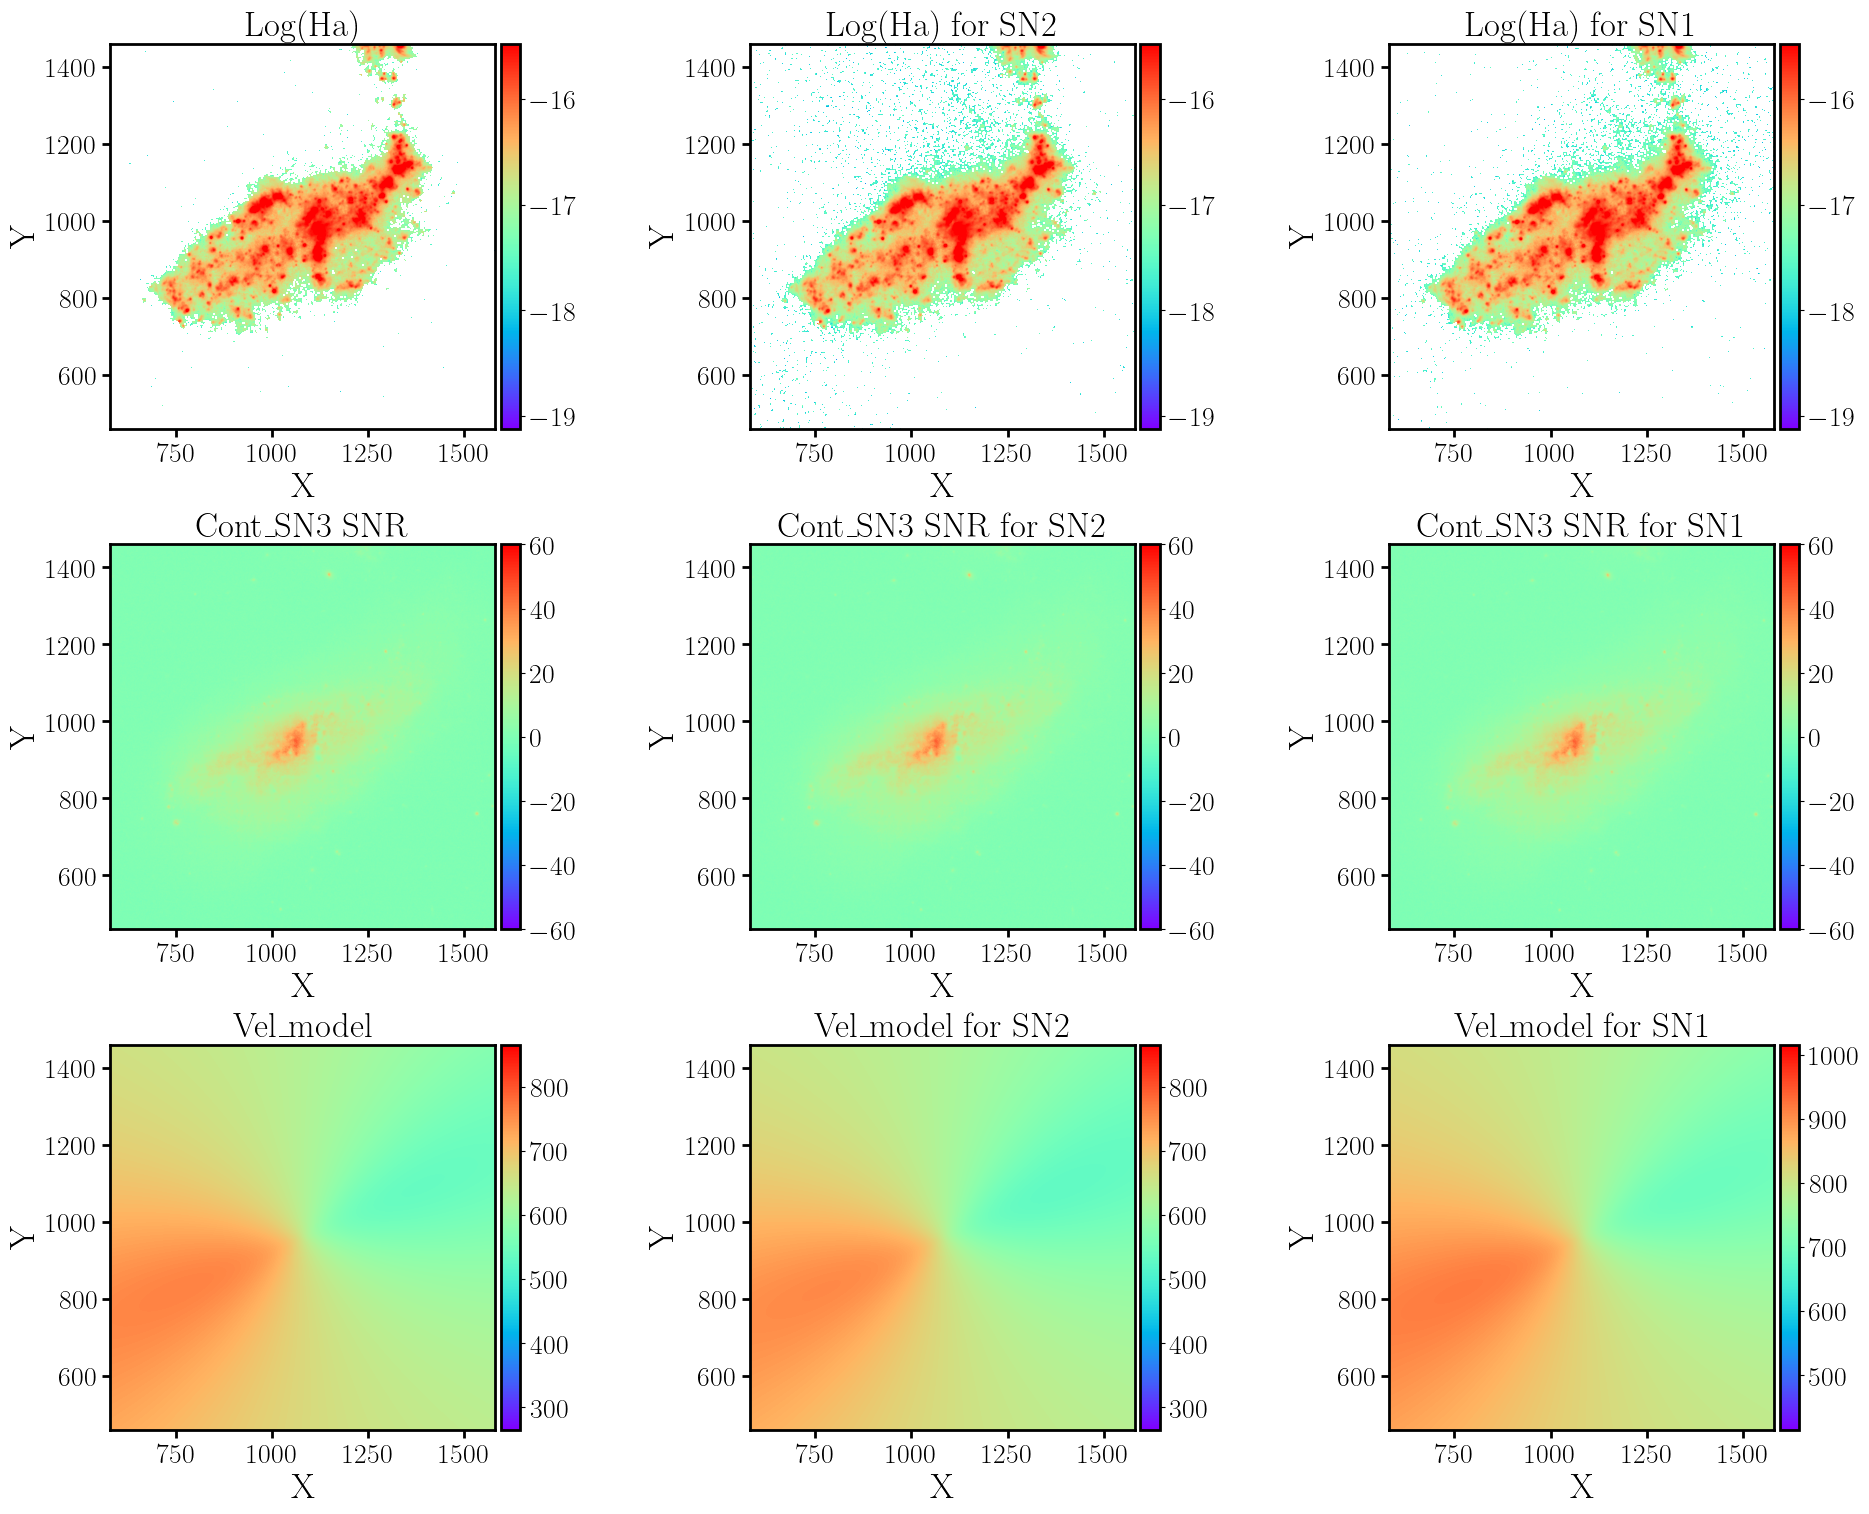

In [12]:
# Check

#flux_ha_for2 = fits.getdata(data_paths_dict['flux_Halpha_aligforSN2'])
#flux_ha_for1 = fits.getdata(data_paths_dict['flux_Halpha_aligforSN1'])
#cont3_snr_for2 = fits.getdata(data_paths_dict['cont3_snr_aligforSN2'])
#cont3_snr_for1 = fits.getdata(data_paths_dict['cont3_snr_aligforSN1'])



xgal1,xgal2,ygal1,ygal2 = xc-500,xc+500,yc-500,yc+500

%matplotlib inline

nyy, nxx, ip = 3, 3, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.3,wspace=0.1)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,flux_ha,flux_ha,xgal1,xgal2,ygal1,ygal2,1,1,99,1)
plt.title('Log(Ha)',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,flux_ha_for2,flux_ha,xgal1,xgal2,ygal1,ygal2,1,1,99,1)
plt.title('Log(Ha) for SN2',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,flux_ha_for1,flux_ha,xgal1,xgal2,ygal1,ygal2,1,1,99,1)
plt.title('Log(Ha) for SN1',size=25)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(0,0,cont3_snr,cont3_snr,xgal1,xgal2,ygal1,ygal2,1,-60,60,1)
plt.title('Cont_SN3 SNR',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(0,0,cont3_snr_for2,cont3_snr,xgal1,xgal2,ygal1,ygal2,1,-60,60,1)
plt.title('Cont_SN3 SNR for SN2',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(0,0,cont3_snr_for1,cont3_snr,xgal1,xgal2,ygal1,ygal2,1,-60,60,1)
plt.title('Cont_SN3 SNR for SN1',size=25)


vsys=np.copy(gal_vel)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(0,0,vel_mod3_obs,vel_mod3_obs,xgal1,xgal2,ygal1,ygal2,1,-300+vsys,+300+vsys,1)
plt.title('Vel_model',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(0,0,vel_mod2_obs_for2,vel_mod3_obs,xgal1,xgal2,ygal1,ygal2,1,-300+vsys,+300+vsys,1)
plt.title('Vel_model for SN2',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(0,0,vel_mod1_obs_for1,vel_mod3_obs,xgal1,xgal2,ygal1,ygal2,1,-150+vsys,+450+vsys,1)
plt.title('Vel_model for SN1',size=25)

## 3. Masks for absorption 

61 113


unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: invalid value encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: divide by zero encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,



Text(0.5, 1.0, 'Mask _ Continuum SN1')

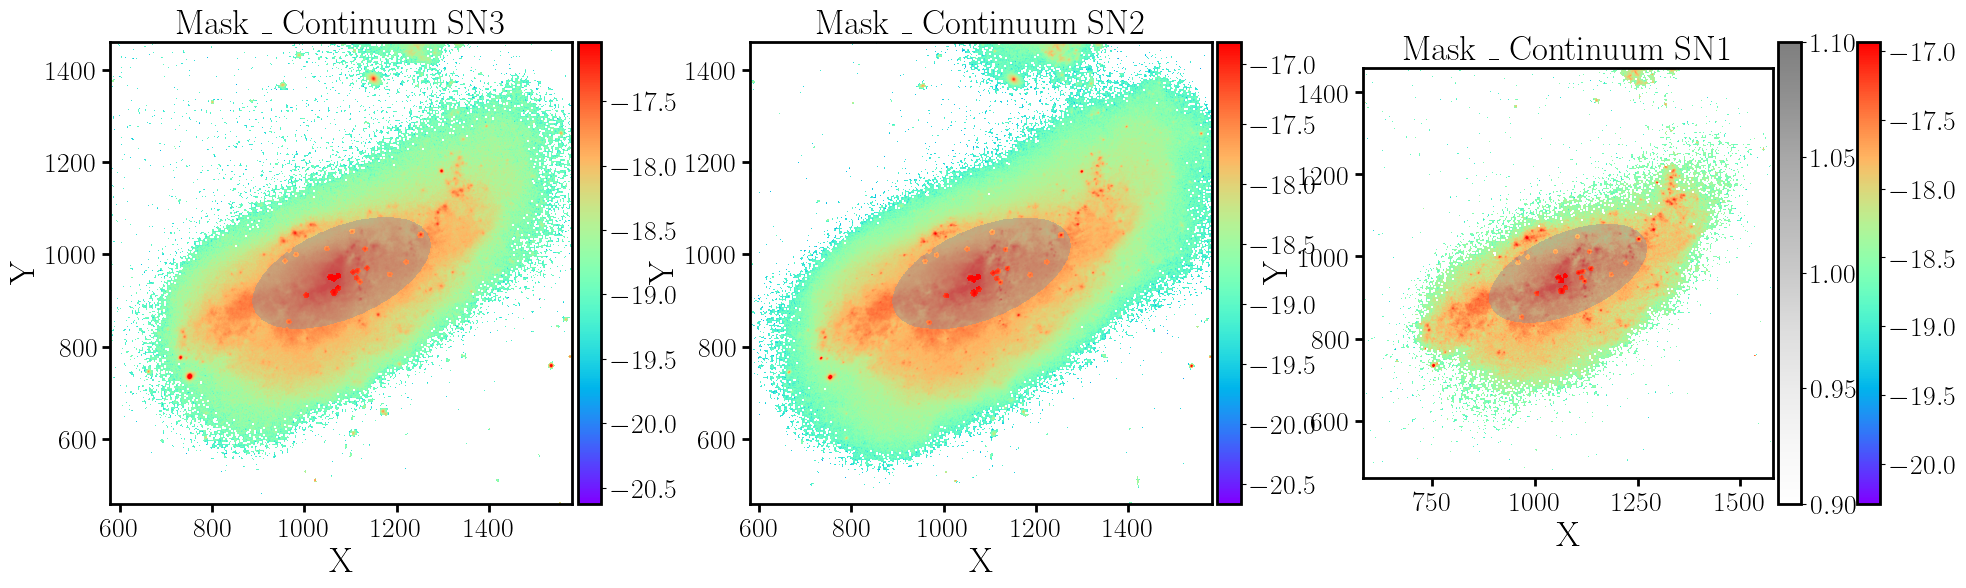

In [124]:
#1) for nuclear region

print(incd,pad)
inc = np.radians(incd)
pa  = np.radians(pad)+(np.pi/2)

imgal   = np.copy(cont3)
imimgal = np.copy(imgal)
y, x = np.mgrid[0:2064, 0:2048]
r1=35
xt = x - xc
yt = y - yc
a  = r1    
b  = r1 * np.cos(inc)  
xp = xt*np.cos(pa) + yt*np.sin(pa)
yp = -xt*np.sin(pa) + yt*np.cos(pa)
mask = (xp/a)**2 + (yp/b)**2
imgal[mask > r1] = 1
imgal[maskbg3 == starvalue] = 1
imimgal[imgal == 1] = np.nan
masknuc3 = imimgal/imimgal

imgal   = np.copy(cont3)
imimgal = np.copy(imgal)
y, x = np.mgrid[0:2064, 0:2048]
r1=35
xt = x - xc2
yt = y - yc2
a  = r1    
b  = r1 * np.cos(inc)  
xp = xt*np.cos(pa) + yt*np.sin(pa)
yp = -xt*np.sin(pa) + yt*np.cos(pa)
mask = (xp/a)**2 + (yp/b)**2
imgal[mask > r1] = 1
imgal[maskbg2 == starvalue] = 1
imimgal[imgal == 1] = np.nan
masknuc2 = imimgal/imimgal

imgal   = np.copy(cont3)
imimgal = np.copy(imgal)
y, x = np.mgrid[0:2064, 0:2048]
r1=35
xt = x - xc1
yt = y - yc1
a  = r1    
b  = r1 * np.cos(inc)  
xp = xt*np.cos(pa) + yt*np.sin(pa)
yp = -xt*np.sin(pa) + yt*np.cos(pa)
mask = (xp/a)**2 + (yp/b)**2
imgal[mask > r1] = 1
imgal[maskbg1 == starvalue] = 1
imimgal[imgal == 1] = np.nan
masknuc1 = imimgal/imimgal



%matplotlib inline

nyy, nxx, ip = 1, 3, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.3,wspace=0.1)

sizf=500

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont3,cont3,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,masknuc3,masknuc3,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask _ Continuum SN3',size=25)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont2,cont2,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.91,1) 
makeplot(0,2,masknuc2,masknuc2,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask _ Continuum SN2',size=25)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont1,cont1,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,masknuc1,masknuc1,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,1)
plt.title('Mask _ Continuum SN1',size=25)



unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: invalid value encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])



61 113


unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: divide by zero encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,



Text(0.5, 1.0, 'Mask + Continuum SN1')

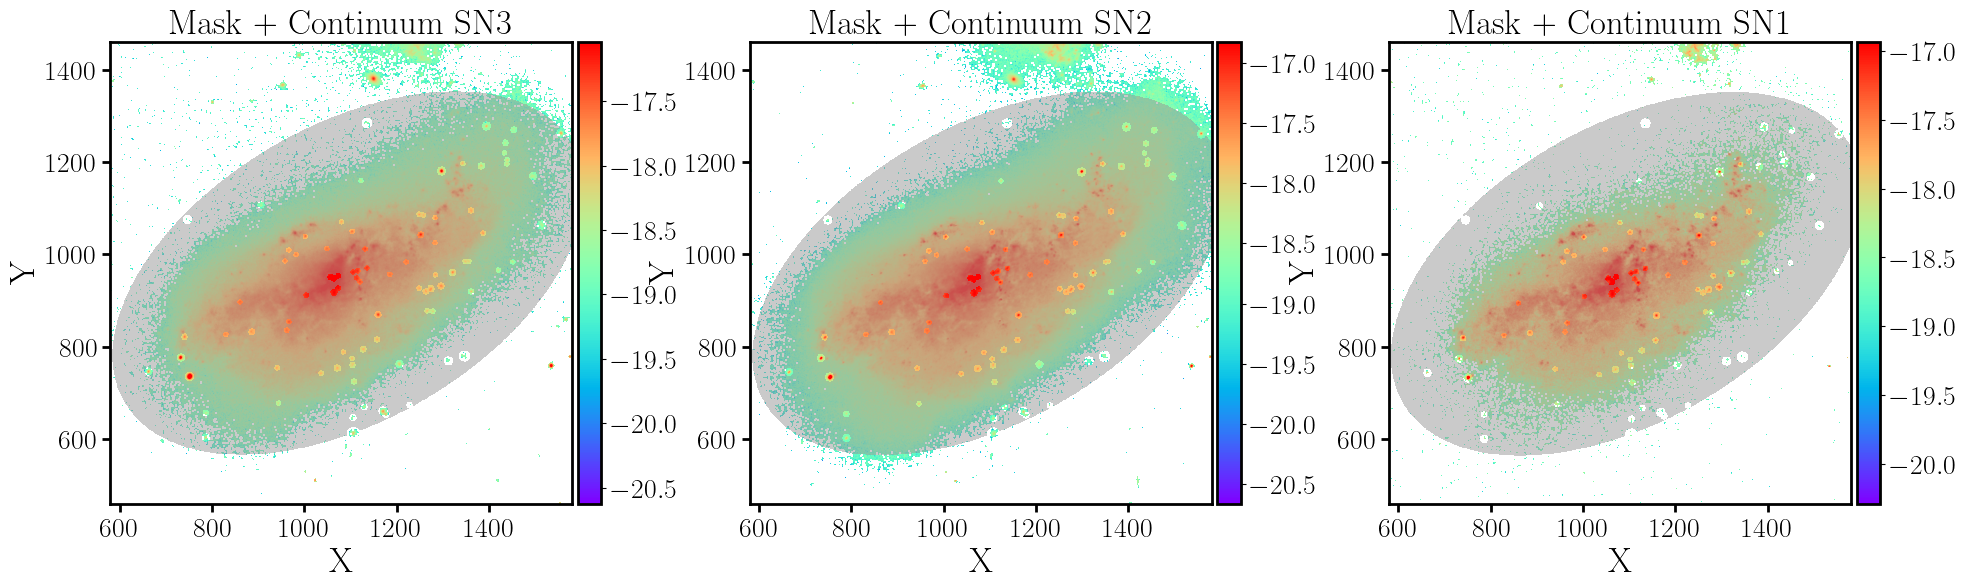

In [14]:
#2) disk 
print(incd,pad)
inc = np.radians(55)
pa  = np.radians(120)+(np.pi/2)



y, x = np.mgrid[0:2064, 0:2048]

imgal = np.copy(cont3)
imimgal=np.copy(imgal)
r1 = 68 #55
xt = x - xc-15
yt = y - yc
a  = r1    
b  = r1 * np.cos(inc)  
xp = xt*np.cos(pa) + yt*np.sin(pa)
yp = -xt*np.sin(pa) + yt*np.cos(pa)
mask = (xp/a)**2 + (yp/b)**2
imgal[mask > r1] = 1
imgal[maskbg3 == starvalue] = 1
imimgal[imgal == 1] = np.nan
maskdisk3 = imimgal/imimgal

imgal = np.copy(cont3)
imimgal=np.copy(imgal)
xt = x - xc2-15
yt = y - yc2 
xp = xt*np.cos(pa) + yt*np.sin(pa)
yp = -xt*np.sin(pa) + yt*np.cos(pa)
mask = (xp/a)**2 + (yp/b)**2
imgal[mask > r1] = 1
imgal[maskbg2 == starvalue] = 1
imimgal[imgal == 1] = np.nan
maskdisk2 = imimgal/imimgal


imgal = np.copy(cont3)
imimgal=np.copy(imgal)
xt = x - xc1-15
yt = y - yc1
xp = xt*np.cos(pa) + yt*np.sin(pa)
yp = -xt*np.sin(pa) + yt*np.cos(pa)
mask = (xp/a)**2 + (yp/b)**2
imgal[mask > r1] = 1
imgal[maskbg1 == starvalue] = 1
imimgal[imgal == 1] = np.nan
maskdisk1 = imimgal/imimgal


%matplotlib inline

nyy, nxx, ip = 1, 3, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.3,wspace=0.1)

sizf=500

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont3,cont3,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk3,maskdisk3,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN3',size=25)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont2,cont2,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk2,maskdisk2,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN2',size=25)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont1,cont1,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk1,maskdisk1,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN1',size=25)



unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: invalid value encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: divide by zero encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,



Text(0.5, 1.0, 'Mask + Continuum SN1')

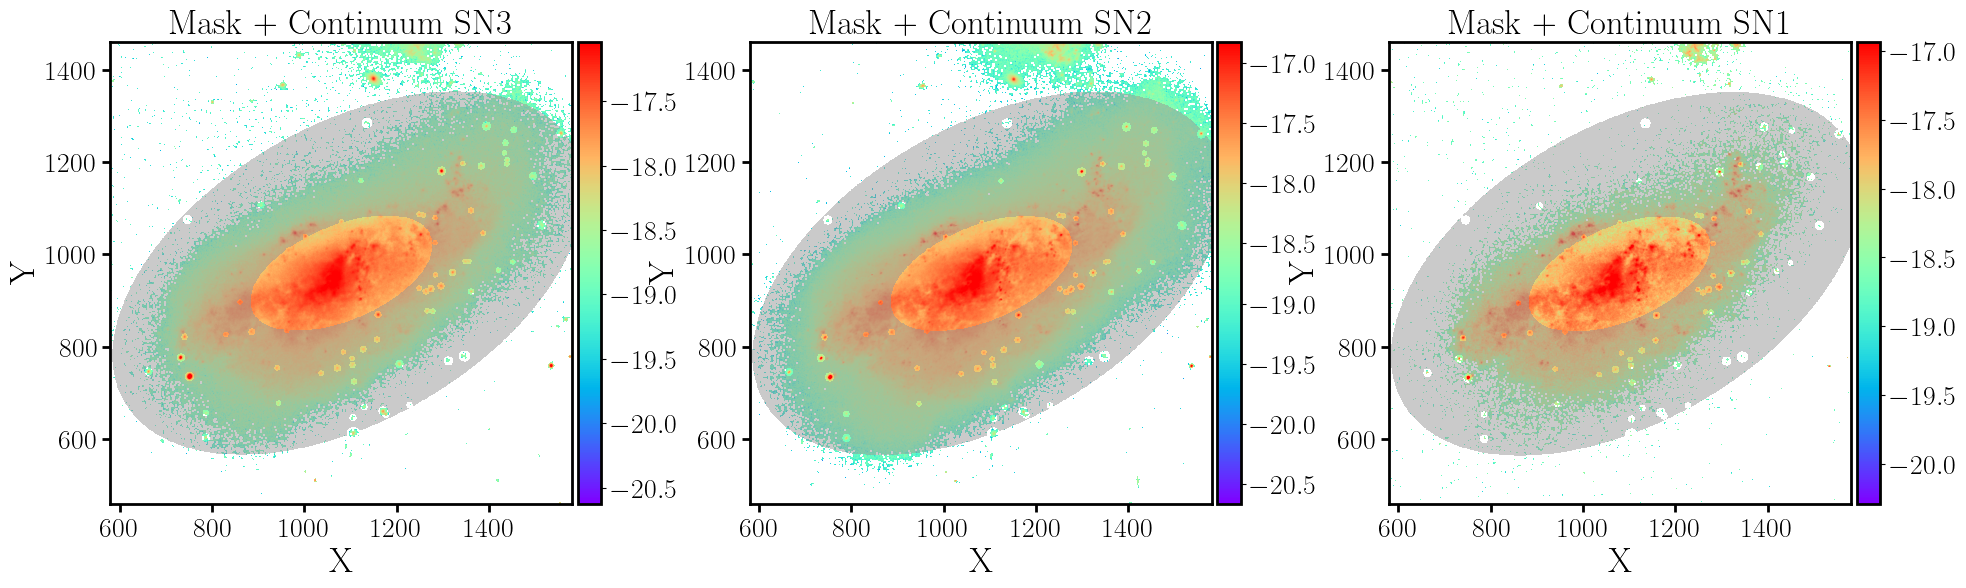

In [15]:
#2b) around nuclear region East

maskdisk1_out = np.copy(maskdisk1)
maskdisk1_out[masknuc1 == 1] = np.nan
maskdisk2_out = np.copy(maskdisk2)
maskdisk2_out[masknuc2 == 1] = np.nan
maskdisk3_out = np.copy(maskdisk3)
maskdisk3_out[masknuc3 == 1] = np.nan


%matplotlib inline

nyy, nxx, ip = 1, 3, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.3,wspace=0.1)

sizf=500


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont3,cont3,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk3_out,maskdisk3_out,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN3',size=25)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont2,cont2,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk2_out,maskdisk2_out,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN2',size=25)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont1,cont1,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk1_out,maskdisk1_out,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN1',size=25)


unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: invalid value encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: divide by zero encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,



Text(0.5, 1.0, 'Mask + Continuum SN1')

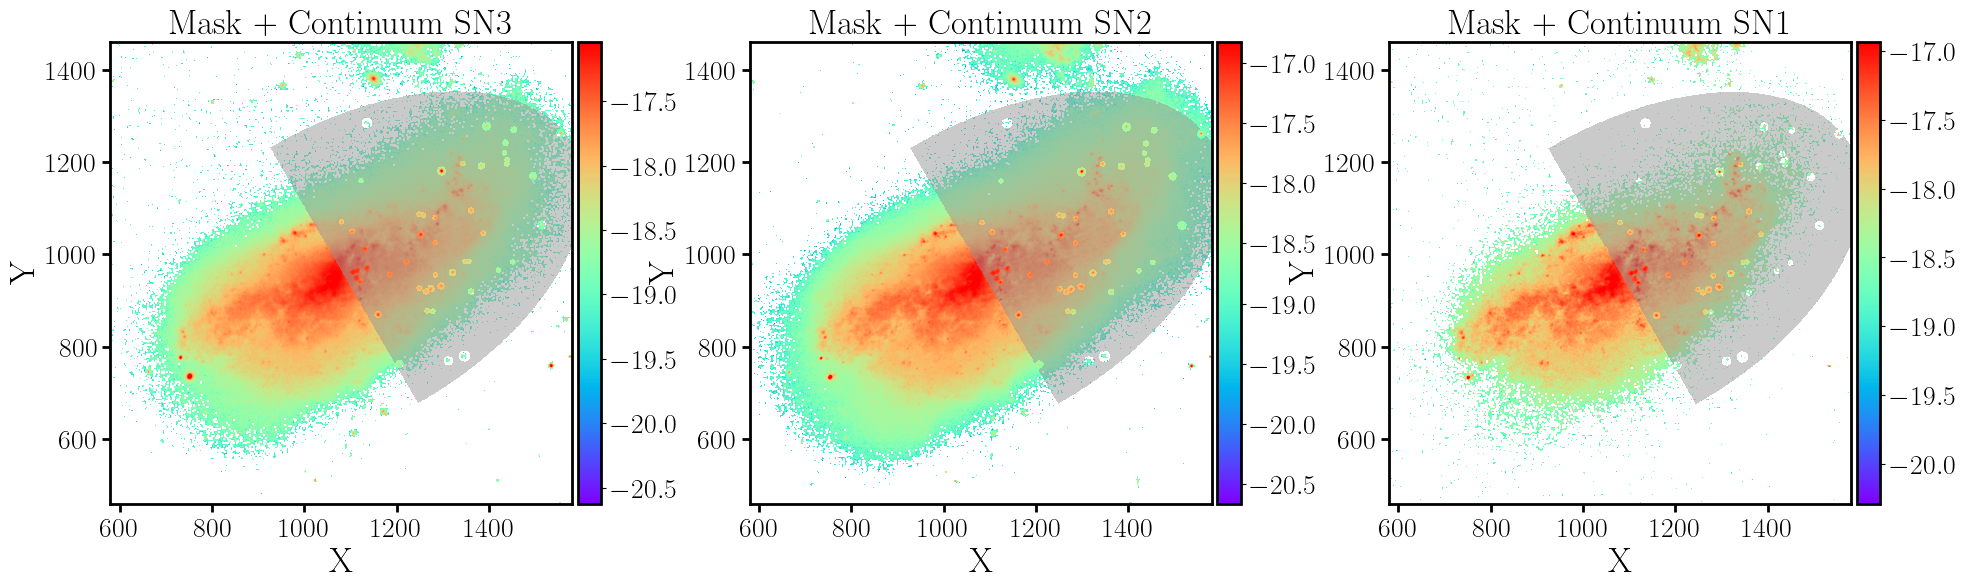

In [16]:
#2c) disk E

y, x = np.mgrid[0:2064, 0:2048]

imgal  = np.copy(cont3)
imimgal=np.copy(maskdisk3)
angd=30
xt = x - xc
yt = y - yc
theta = np.deg2rad(angd)
dx = np.sin(theta)      
dy = -np.cos(theta)
cross = xt * dy - yt * dx
mask = cross > 0
imgal[mask] = 1
imimgal[imgal == 1] = np.nan
maskdisk3_e = imimgal/imimgal

imgal = np.copy(cont3)
imimgal=np.copy(maskdisk2)
xt = x - xc2
yt = y - yc2
theta = np.deg2rad(angd)
dx = np.sin(theta)      
dy = -np.cos(theta)
cross = xt * dy - yt * dx
mask = cross > 0
imgal[mask] = 1
imimgal[imgal == 1] = np.nan
maskdisk2_e = imimgal/imimgal

imgal = np.copy(cont3)
imimgal=np.copy(maskdisk1)
xt = x - xc1
yt = y - yc1
theta = np.deg2rad(angd)
dx = np.sin(theta)      
dy = -np.cos(theta)
cross = xt * dy - yt * dx
mask = cross > 0
imgal[mask] = 1
imimgal[imgal == 1] = np.nan
maskdisk1_e = imimgal/imimgal



%matplotlib inline

nyy, nxx, ip = 1, 3, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.3,wspace=0.1)

sizf=500


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont3,cont3,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk3_e,maskdisk3_e,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN3',size=25)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont2,cont2,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk2_e,maskdisk2_e,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN2',size=25)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont1,cont1,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk1_e,maskdisk1_e,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN1',size=25)



unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: invalid value encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: divide by zero encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,



Text(0.5, 1.0, 'Mask + Continuum SN1')

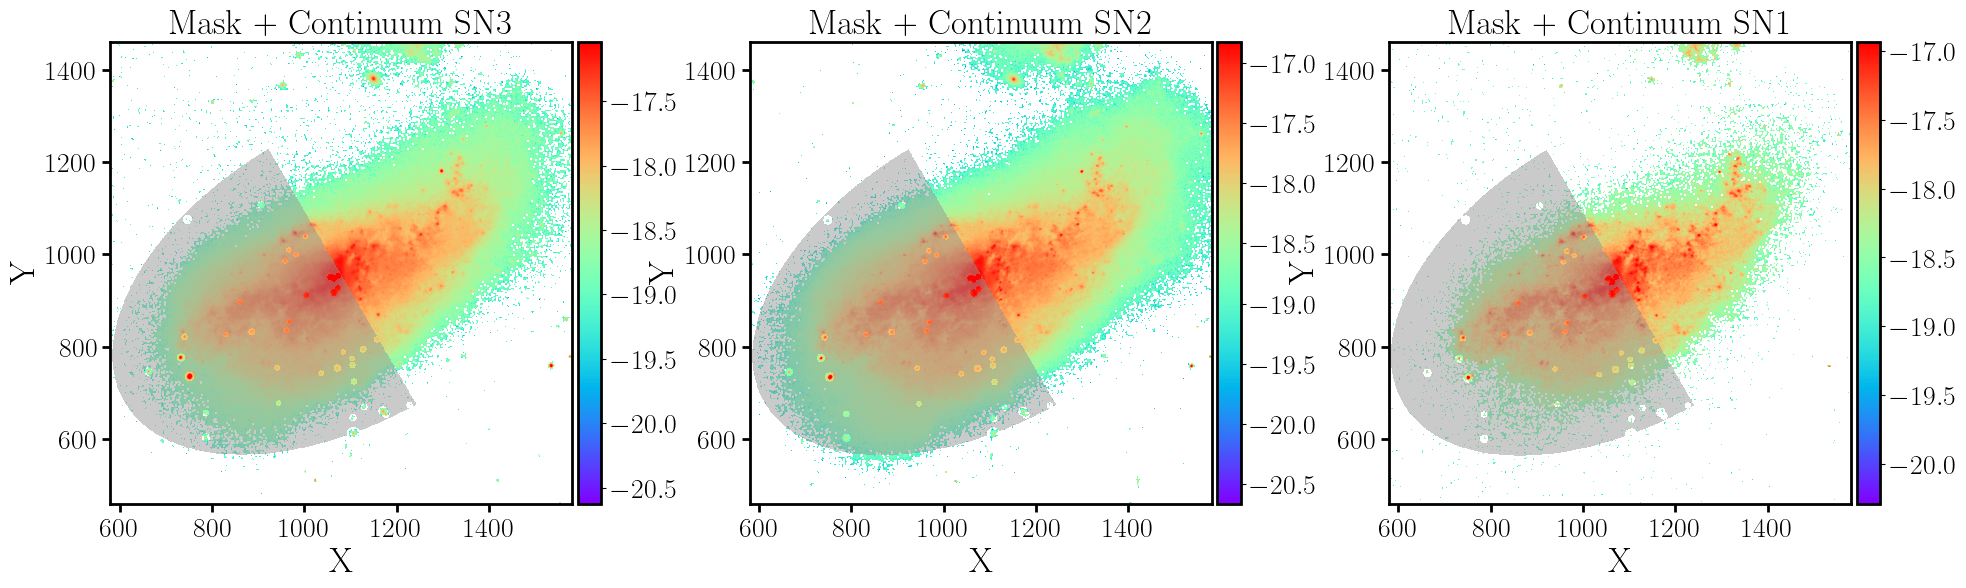

In [17]:
#2c) disk W

y, x = np.mgrid[0:2064, 0:2048]

imgal  = np.copy(cont3)
imimgal=np.copy(maskdisk3)
angd=30
xt = x - xc
yt = y - yc
theta = np.deg2rad(angd)
dx = np.sin(theta)      
dy = -np.cos(theta)
cross = xt * dy - yt * dx
mask = cross <= 0
imgal[mask] = 1
imimgal[imgal == 1] = np.nan
maskdisk3_w = imimgal/imimgal

imgal = np.copy(cont3)
imimgal=np.copy(maskdisk2)
xt = x - xc2
yt = y - yc2
theta = np.deg2rad(angd)
dx = np.sin(theta)      
dy = -np.cos(theta)
cross = xt * dy - yt * dx
mask = cross <= 0
imgal[mask] = 1
imimgal[imgal == 1] = np.nan
maskdisk2_w = imimgal/imimgal

imgal = np.copy(cont3)
imimgal=np.copy(maskdisk1)
xt = x - xc1
yt = y - yc1
theta = np.deg2rad(angd)
dx = np.sin(theta)      
dy = -np.cos(theta)
cross = xt * dy - yt * dx
mask = cross <= 0
imgal[mask] = 1
imimgal[imgal == 1] = np.nan
maskdisk1_w = imimgal/imimgal



%matplotlib inline

nyy, nxx, ip = 1, 3, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.3,wspace=0.1)

sizf = 500

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont3,cont3,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk3_w,maskdisk3_w,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN3',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont2,cont2,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk2_w,maskdisk2_w,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN2',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont1,cont1,xc-sizf,xc+sizf,yc-sizf,yc+sizf,1,1,99.9,1) 
makeplot(0,2,maskdisk1_w,maskdisk1_w,xc-sizf,xc+sizf,yc-sizf,yc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN1',size=25)



unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: invalid value encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])



35 5


unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:9: RuntimeWarning: divide by zero encountered in log10
  vvi=np.log10(imagevvi[y1:y2,x1:x2])

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/3253553162.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(imagein), cmap=col, origin='lower',alpha=a,



Text(0.5, 1.0, 'Mask + Continuum SN1')

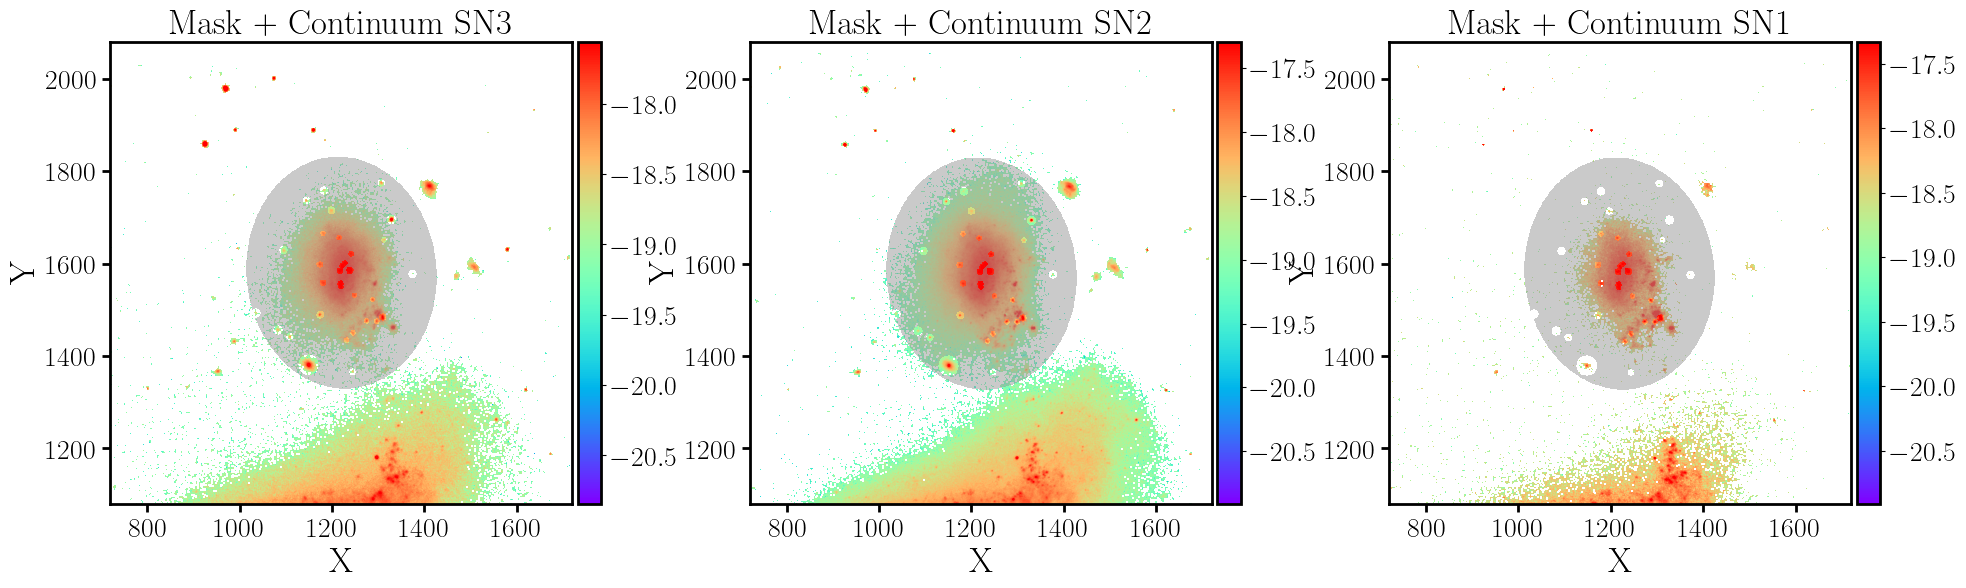

In [18]:
#3) companion


imgal = np.copy(cont3)
incd2,pad2=35,5
print(incd2,pad2)
inc = np.radians(incd2)
pa  = np.radians(pad2)+(np.pi/2)
xcc,ycc=1220,1580
r3,  d3   = wcs3.wcs_pix2world(xcc,ycc, 0)
xcc2, ycc2  = wcs2.wcs_world2pix(r3,d3, 0)
xcc2, ycc2  = np.round(xcc2,0).astype(int),np.round(ycc2,0).astype(int)
xcc1, ycc1 = wcs1.wcs_world2pix(r3,d3, 0)
xcc1, ycc1 = np.round(xcc1,0).astype(int),np.round(ycc1,0).astype(int)

y, x = np.mgrid[0:2064, 0:2048]
imgal = np.copy(cont3)
imimgal=np.copy(imgal)
r1=40
xt = x - xcc
yt = y - ycc
a  = r1    
b  = r1 * np.cos(inc)  
xp = xt*np.cos(pa) + yt*np.sin(pa)
yp = -xt*np.sin(pa) + yt*np.cos(pa)
mask = (xp/a)**2 + (yp/b)**2
imgal[mask >= r1] = 1
imgal[maskbg3 == starvalue] = 1
imimgal[imgal == 1] = np.nan
maskcom3 = imimgal/imimgal

imgal = np.copy(cont3)
imimgal=np.copy(imgal)
xt = x - xcc2
yt = y - ycc2
xp = xt*np.cos(pa) + yt*np.sin(pa)
yp = -xt*np.sin(pa) + yt*np.cos(pa)
mask = (xp/a)**2 + (yp/b)**2
imgal[mask >= r1] = 1
imgal[maskbg2 == starvalue] = 1
imimgal[imgal == 1] = np.nan
maskcom2 = imimgal/imimgal

imgal = np.copy(cont3)
imimgal=np.copy(imgal)
xt = x - xcc1
yt = y - ycc1
xp = xt*np.cos(pa) + yt*np.sin(pa)
yp = -xt*np.sin(pa) + yt*np.cos(pa)
mask = (xp/a)**2 + (yp/b)**2
imgal[mask >= r1] = 1
imgal[maskbg1 == starvalue] = 1
imimgal[imgal == 1] = np.nan
maskcom1 = imimgal/imimgal


%matplotlib inline

nyy, nxx, ip = 1, 3, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.3,wspace=0.1)

sizf = 500

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont3,cont3,xcc-sizf,xcc+sizf,ycc-sizf,ycc+sizf,1,1,99.9,1) 
makeplot(0,2,maskcom3,maskcom3,xcc-sizf,xcc+sizf,ycc-sizf,ycc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN3',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont2,cont2,xcc-sizf,xcc+sizf,ycc-sizf,ycc+sizf,1,1,99.9,1) 
makeplot(0,2,maskcom2,maskcom2,xcc-sizf,xcc+sizf,ycc-sizf,ycc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN2',size=25)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,0,cont1,cont1,xcc-sizf,xcc+sizf,ycc-sizf,ycc+sizf,1,1,99.9,1) 
makeplot(0,2,maskcom1,maskcom1,xcc-sizf,xcc+sizf,ycc-sizf,ycc+sizf,0.5,0.9,1.1,0)
plt.title('Mask + Continuum SN1',size=25)



# **3. Useful functions** 

In [19]:
def plot_abs_spectrum(wlines,
    wave_sn1: npt.NDArray[np.float64],
    wave_sn2: npt.NDArray[np.float64],
    wave_sn3: npt.NDArray[np.float64],
    flux_sn1: npt.NDArray[np.float64],
    flux_sn2: npt.NDArray[np.float64],
    flux_sn3: npt.NDArray[np.float64],
) -> None:
    """
    """
    flux_sn1_copy = np.copy(flux_sn1)
    flux_sn2_copy = np.copy(flux_sn2)
    flux_sn3_copy = np.copy(flux_sn3)
    
    # Exponant of a power of 10
    #exp = int(np.floor(np.log10(np.nanmax(flux_sn3)))) 
    exp = int(np.floor(np.log10(np.nanmax([*flux_sn1, *flux_sn2, *flux_sn3,]))))
    # Multiplie by 10^exp to get rid of scientific notation on the top of the plot
    flux_sn1_copy *= 10**-exp
    flux_sn2_copy *= 10**-exp
    flux_sn3_copy *= 10**-exp

    # Create figure
    fig = plt.figure(figsize=(20, 8), constrained_layout=True)
    
    # Axes of the figure
    ax1 = plt.subplot2grid(shape=(1, 4), loc=(0, 0), colspan=1)
    ax2 = plt.subplot2grid(shape=(1, 4), loc=(0, 1), colspan=1, sharey=ax1)
    ax3 = plt.subplot2grid(shape=(1, 4), loc=(0, 2), colspan=1, sharey=ax1)
    ax4 = plt.subplot2grid(shape=(1, 4), loc=(0, 3), colspan=1)

    # Height/width ratio for ax1, ax2 and ax3
    ax1.set_box_aspect(1)
    ax2.set_box_aspect(1)
    ax3.set_box_aspect(1)

    axes = [ax1, ax2, ax3, ax4]

    # Hides y-axis ticks between ax1, ax2 and ax3 
    ax1.spines['right'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax3.spines['left'].set_visible(False)
    ax1.tick_params(axis='both', which = 'both', right=False)
    ax2.tick_params(axis='both', which = 'both', labelleft=False, left=False, right=False)
    ax3.tick_params(axis='both', which = 'both', labelleft=False, left=False)   
    
    # Plots spectra
    ax1.plot(wave_sn3, flux_sn3_copy, c="#3e82a0", linewidth=2)
    ax2.plot(wave_sn2, flux_sn2_copy, c="#3e82a0", linewidth=2)
    ax3.plot(wave_sn1, flux_sn1_copy, c="#3e82a0", linewidth=2)

    # Show continuum's S/N
    snr_cont_sn1 = np.nanmedian(flux_sn1_copy) * 10 ** exp / noise_sn1
    snr_cont_sn2 = np.nanmedian(flux_sn2_copy) * 10 ** exp / noise_sn2
    snr_cont_sn3 = np.nanmedian(flux_sn3_copy) * 10 ** exp / noise_sn3
    ax1.text(ax1.get_xlim()[0] + 50, ax1.get_ylim()[0] + 0.1, f'S/N$_\mathrm{{continuum}}$ = {snr_cont_sn3:.2f}')
    ax2.text(ax2.get_xlim()[0] + 50, ax2.get_ylim()[0] + 0.1, f'S/N$_\mathrm{{continuum}}$ = {snr_cont_sn2:.2f}')
    ax3.text(ax3.get_xlim()[0] + 50, ax3.get_ylim()[0] + 0.1, f'S/N$_\mathrm{{continuum}}$ = {snr_cont_sn1:.2f}')

    # x and y axes labels of the spectra plot
    ax2.set_xlabel(rf"Wavenumber [cm$^{{-1}}$]")
    ax1.set_ylabel(rf"Flux 10$^{{{exp}}}$ erg/s/cm$^{2}$/\AA")
    ax2.set_title("Stellar Population Spectrum")

    # Idicates the position of absorption lines 
    plot_lineid_abs(ax1, wave_sn3, flux_sn3_copy, [1e8/6495], ['FeI 6495'])
    plot_lineid_abs(ax1, wave_sn3, flux_sn3_copy, [1e8/6562], ['Ha'])
    plot_lineid_abs(ax1, wave_sn3, flux_sn3_copy, [1e8/6548], ['NII'])
    plot_lineid_abs(ax1, wave_sn3, flux_sn3_copy, [1e8/6583], ['NII'])
    plot_lineid_abs(ax1, wave_sn3, flux_sn3_copy, [1e8/6716], ['SII'])
    plot_lineid_abs(ax1, wave_sn3, flux_sn3_copy, [1e8/6731], ['SII'])    
    plot_lineid_abs(ax2, wave_sn2, flux_sn2_copy, [1e8/4861], ['Hb'])
    plot_lineid_abs(ax2, wave_sn2, flux_sn2_copy, [1e8/4959], ['OIII'])
    plot_lineid_abs(ax2, wave_sn2, flux_sn2_copy, [1e8/5007], ['OIII'])    
    plot_lineid_abs(ax3, wave_sn1, flux_sn1_copy, [1e8/3727], ['OII'])
    plot_lineid_abs(ax3, wave_sn1, flux_sn1_copy, [1e8/3835], ['H9'])
    plot_lineid_abs(ax3, wave_sn1, flux_sn1_copy, [1e8/3798], ['H10'])
    plot_lineid_abs(ax3, wave_sn1, flux_sn1_copy, [1e8/3771], ['H11'])
    plot_lineid_abs(ax3, wave_sn1, flux_sn1_copy, [1e8/3750], ['H12'])
    plot_lineid_abs(ax3, wave_sn1, flux_sn1_copy, [1e8/3734], ['H13'])
    plot_lineid_abs(ax3, wave_sn1, flux_sn1_copy, [1e8/3721], ['H14'])
    plot_lineid_abs(ax3, wave_sn1, flux_sn1_copy, [1e8/3710], ['H15'])
    

    # Shows the pixels used to create the absorption spectra
    plot_px2use(ax4)
    
    # Broken axis
    d = 1  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", 
                  color='k', mec='k', mew=1, clip_on=False )
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax3.plot([0, 0], [0, 1], transform=ax3.transAxes, **kwargs)
    ax2.plot([0, 0, 1, 1], [0, 1, 0, 1], transform=ax2.transAxes, **kwargs)
    
    # fig.savefig('spectre_spectre.png', dpi=100)
    plt.show()
    fig.savefig(Folder+'0-Abspix_'+tit+'.jpeg',bbox_inches = 'tight')
    fig.clf()
    plt.close(fig)


def plot_lineid_abs(ax, wavenb, spectrum, line_wave, line_label):
    """
    Idicates the position of absorption lines 
     
    params:
        ax (Axes): Subplot in a figure
        wavenb (numpy,array): Array of wavenumbers
        spectrum (numpy,array): Spectrum
        line_wave (list): Lines' positions (cm^-1)
        line_label (list): Lines' labels 
    """ 
    lineid_plot.plot_line_ids(
        wavenb, 
        spectrum,
        line_wave,
        line_label,
        label1_size = 18,
        arrow_tip=1.2,  # will determine ymax
        ax = ax
    )


def plot_px2use(ax):
    """ 
    Shows the pixels used to create the absorption spectra 
    
    params:
        ax (Axes): Subplot in a figure
    """
    # Pixels used to build the absorption spectrum
    y, x = np.where(px2use)
    
    # Plots deepframes
    ax.imshow(
        np.log10(deepframe_sn3), origin='lower', cmap='Grays', 
        vmin=np.nanpercentile(np.log10(deepframe_sn3), 10), 
        vmax=np.nanpercentile(np.log10(deepframe_sn3), 99.9)
    )

    
    ax.scatter(x, y, s=1, linewidth=0, color="crimson", marker="s")

    # Crop    
    ax.set_xlim(xc - radius_mask - 100, xc + radius_mask + 100)
    ax.set_ylim(yc - radius_mask - 100, yc + radius_mask + 100)
    
    # x and y axes labels
    ax.set_xlabel(f'x [px]')
    ax.set_ylabel(f'y [px]')
    ax.set_title(f'Deepframe SN3 \n Nb. px. used (in red): {np.count_nonzero(px2use)}')



unknown|WARNING| <>:57: DeprecationWarning: invalid escape sequence '\m'

unknown|WARNING| <>:58: DeprecationWarning: invalid escape sequence '\m'

unknown|WARNING| <>:59: DeprecationWarning: invalid escape sequence '\m'

unknown|WARNING| <>:57: DeprecationWarning: invalid escape sequence '\m'

unknown|WARNING| <>:58: DeprecationWarning: invalid escape sequence '\m'

unknown|WARNING| <>:59: DeprecationWarning: invalid escape sequence '\m'

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/876963996.py:57: DeprecationWarning: invalid escape sequence '\m'
  ax1.text(ax1.get_xlim()[0] + 50, ax1.get_ylim()[0] + 0.1, f'S/N$_\mathrm{{continuum}}$ = {snr_cont_sn3:.2f}')

unknown|WARNING| /var/folders/fr/qtxrvp4d05g2y25w1fx7jwwh0000gn/T/ipykernel_30022/876963996.py:58: DeprecationWarning: invalid escape sequence '\m'
  ax2.text(ax2.get_xlim()[0] + 50, ax2.get_ylim()[0] + 0.1, f'S/N$_\mathrm{{continuum}}$ = {snr_cont_sn2:.2f}')

unknown|WARNING| /var/folders/fr/q

# **4. Absorption spectrum** 

## **4.1 Extracting stellar pop spectrum 

In [98]:
# Enter here the  limits for the Ha_flux and SNR_continuum
# so the integrated spectrum will only keep pixel bellow thr_Ha and above thr_SNRc

tit = 'Com_SNR5_Ha5e-18_vobs_m50m50m50'
thr_Ha   = 5e-18
thr_SNRc = 5.

abs_spectr1 = AbsSpectrum(maskcom1, flux_ha_for1, cont3_snr_for1,  thr_Ha, thr_SNRc)
abs_spectr2 = AbsSpectrum(maskcom2, flux_ha_for2, cont3_snr_for2,  thr_Ha, thr_SNRc)
abs_spectr3 = AbsSpectrum(maskcom3, flux_ha,      cont3_snr     ,  thr_Ha, thr_SNRc)
print(abs_spectr1)

# Extracting absorption spectrum
# Specify the resolution of the model used, so if datacubes have a better resolution it will be degraded
res_model = 2.51

spectrum_sn1, noise_sn1 = abs_spectr1.get_abs_spectrum(cube_sn1, vel_com1_obs-50, noise_map_sn1, sky_sn1, res_model, median=True)
spectrum_sn2, noise_sn2 = abs_spectr2.get_abs_spectrum(cube_sn2, vel_com2_obs-50, noise_map_sn2, sky_sn2, res_model, median=True)
spectrum_sn3, noise_sn3 = abs_spectr3.get_abs_spectrum(cube_sn3, vel_com3_obs-50, noise_map_sn3, sky_sn3, res_model, median=True)

spectrum_sn1.data /= cal_SN1
spectrum_sn2.data /= cal_SN2
spectrum_sn3.data /= cal_SN3

wavenb_sn1 = spectrum_sn1.get_axis()
wavenb_sn2 = spectrum_sn2.get_axis()
wavenb_sn3 = spectrum_sn3.get_axis()

# To know where there is no nan in the filters...
idx1_sn1, idx2_sn1 = spectrum_sn1.get_filter_bandpass_pix()
idx1_sn2, idx2_sn2 = spectrum_sn2.get_filter_bandpass_pix()
idx1_sn3, idx2_sn3 = spectrum_sn3.get_filter_bandpass_pix()

#print(idx1_sn3,idx2_sn3)
#print(wavenb_sn3[idx1_sn3],wavenb_sn3[idx2_sn3])
#print(1e8/wavenb_sn3[idx1_sn3],1e8/wavenb_sn3[idx2_sn3])
##print(idx1_sn3, wavenb_sn3[idx1_sn3])
##print(idx2_sn3, wavenb_sn3[idx2_sn3])
#print(1e8/6495)

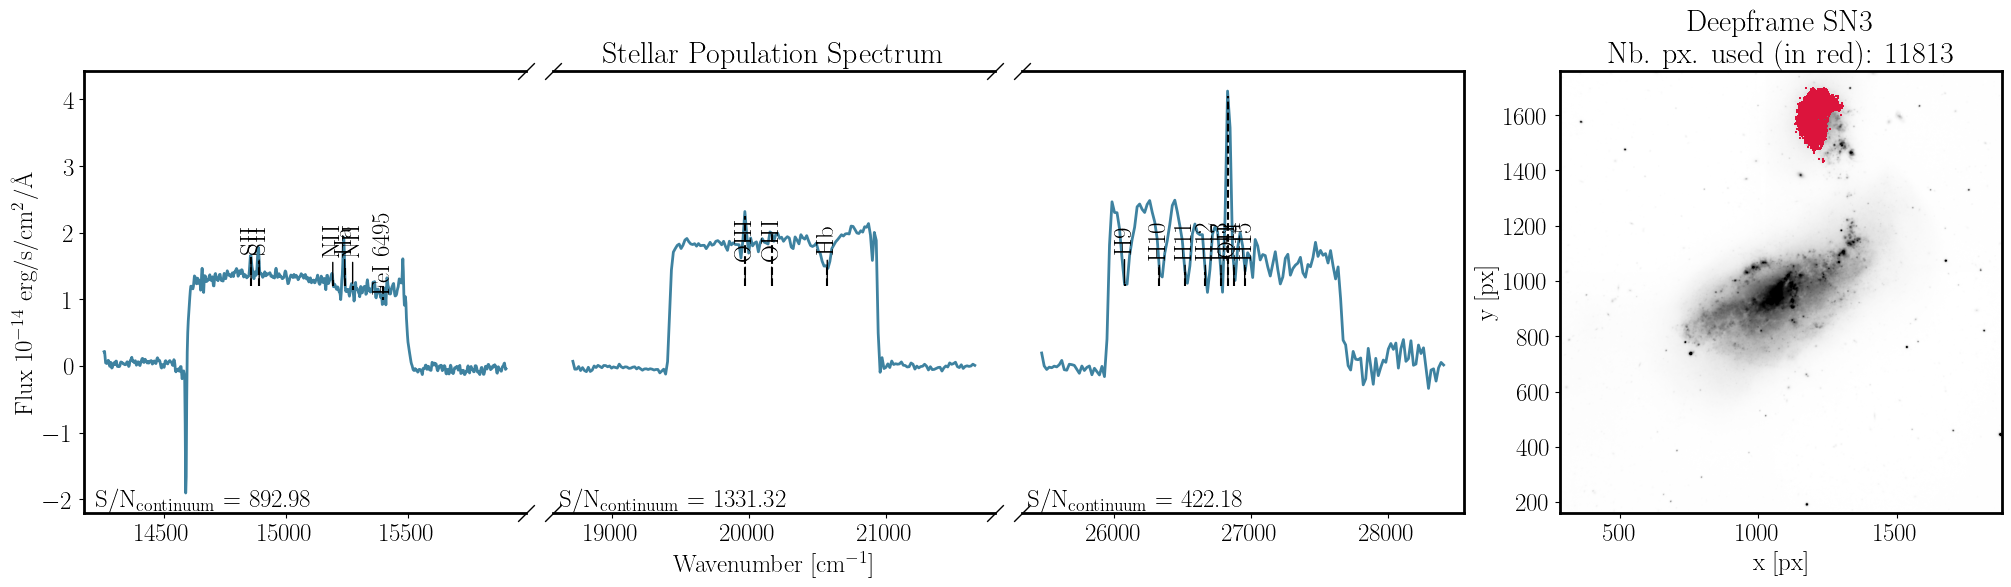

In [99]:
# Pixels to use to build the absorption spectra
radius_mask = 700    #for plotting the pixels used

px2use = abs_spectr3.get_px2use()

# Crop the absorption spectra to the filter bandpass 
#wavenb_sn1_crop = wavenb_sn1[idx1_sn1:idx2_sn1]
#wavenb_sn2_crop = wavenb_sn2[idx1_sn2:idx2_sn2]
#wavenb_sn3_crop = wavenb_sn3[idx1_sn3:idx2_sn3]
#
#flux_sn1_crop = spectrum_sn1.get_real()[idx1_sn1:idx2_sn1]
#flux_sn2_crop = spectrum_sn2.get_real()[idx1_sn2:idx2_sn2]
#flux_sn3_crop = spectrum_sn3.get_real()[idx1_sn3:idx2_sn3]

flux_sn1 = spectrum_sn1.get_real()
flux_sn2 = spectrum_sn2.get_real()
flux_sn3 = spectrum_sn3.get_real()
# Plot absorption spectrum
#plot_abs_spectrum(wlines,wavenb_sn1_crop, wavenb_sn2_crop, wavenb_sn3_crop, flux_sn1_crop, flux_sn2_crop, flux_sn3_crop)
plot_abs_spectrum(wlines,wavenb_sn1, wavenb_sn2, wavenb_sn3, flux_sn1,flux_sn2,flux_sn3)



In [123]:
print(noise_sn3,noise_sn1,noise_sn2)

1.2083634e-17 3.1640294e-17 1.12538816e-17


## **4.2 pPXF fit** 

Emission lines included in gas templates:
['Htheta' 'Heta' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[OIII]5007_d' '[OI]6300_d'
 '[NII]6583_d']
 Best Fit:       Vel     sigma
 comp.  0:       -48       108
 comp.  1:        21       108
Stars Attenuation A_V: 0.217
  Gas Attenuation A_V: 0.000
chi2/DOF: 2917.; DOF: 1061; degree = -1; mdegree = 8
method = capfit; Jac calls: 7; Func calls: 111; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 15/363
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1                Htheta     0.6393    0.0052      21   108
Comp:  1                  Heta     0.3314    0.0052      21   108
Comp:  1                Hdelta      0.000      0.10      21   108
Comp:  1                Hgamma      0.000     0.070      21   108
Comp:  1                 Hbeta

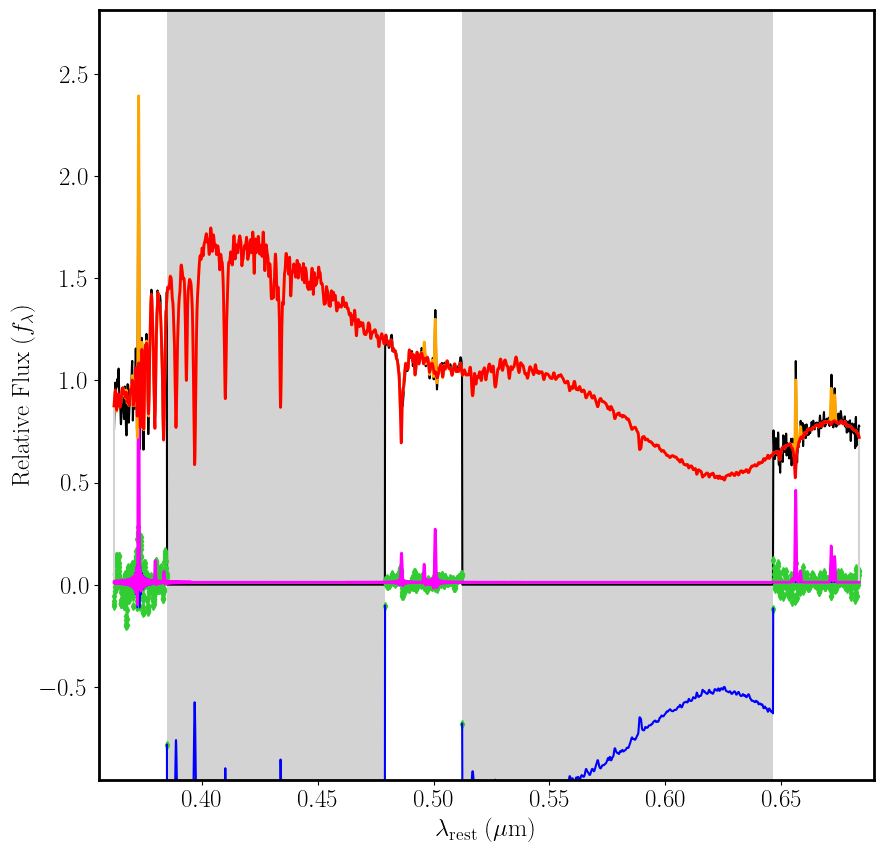

In [100]:
warnings.filterwarnings('ignore')


abs_spectra = [spectrum_sn1, spectrum_sn2, spectrum_sn3]
noise       = [noise_sn1, noise_sn2, noise_sn3]

# Directory where stellar population synthesis templates are stored
sps_dir = "SSP/MILES_PADOVA00_UN_baseFe"  

# Here the ppxf fit starts
fit_ppxf = PpxfFit(abs_spectra, sps_dir, 2.51, noise)
pp, norm_factor = fit_ppxf.get_ppxf_fit()

fig = plt.figure(figsize=(10,10))
pp.plot()

fig.savefig(Folder+'1-PPXF_model_'+tit+'.jpeg',bbox_inches = 'tight')

## Htheta = H10, Heta = H9   ??? why not Hiota=H11 and Hkappa = H12

## **4.3 pPXF fit results compared to data** 

In [101]:
def undersampling_interp(pp, target_axis):
    """
    Takes the full lenght of ppxf spectrum, cuts the part 
    that correspond to de-redshifted SITELLE filters and 
    undersamples it to the data wavenumber spectra.

    params:
        pp (ppxf.ppxf.ppxf): pPXF fit results
        target_axis (numpy.ndarray): [description]
        range (list or tuple): De-redshifted SITELLE filters range (in cm^-1)

    return:
        synthetic_bestfit (numpy.ndarray): Undersampled best fit obtained by pPXF
        synthetic_abs_bestfit (numpy.ndarray): Undersampled absorption best fit obtained by pPXF.
    """
    # Results of the pPXF fit
    wavenb_ppxf = 1e8/np.flip(pp.lam)    # Convert wavelenghts to wavenumbers
    bestfit = np.flip(pp.bestfit)    # Best fit obtained by pPXF
    lines_bestfit = np.flip(pp.gas_bestfit)    # Best fit of the pPXF emission lines

    # Undersampled best fit obtained by pPXF and best fit of the pPXF emission lines
    synthetic_bestfit = interp1d(wavenb_ppxf, bestfit, fill_value='extrapolate')(target_axis)
    synthetic_abs_bestfit = interp1d(wavenb_ppxf, bestfit - lines_bestfit, fill_value='extrapolate')(target_axis)
    
    return synthetic_bestfit, synthetic_abs_bestfit

def plot_abs_spectrum_ppxf(abs_wavenb, abs_spectra, bestfit_ppxf, abs_besfit_ppxf,titfig):
    """
    Plots ppxf fit results and compares it to the original data
    
    params:
        abs_wavenb (list): [description]
        abs_spectra (list): [description]
        bestfit_ppxf (list): [description]
        abs_besfit_ppxf (list): [description]
    """    
    # Exponant of a power of 10
    #exp = int(np.floor(np.log10(np.nanmax(np.concatenate(abs_spectra)))))
    exp = int(np.floor(np.log10(np.nanmax(abs_spectra[2]))))
    

    # Makes a copy of function arguments
    abs_spectra_copy = abs_spectra.copy()
    bestfit_ppxf_copy =  bestfit_ppxf.copy()
    abs_besfit_ppxf_copy = abs_besfit_ppxf.copy()
    
    # Multiply by 10^exp to get rid of scientific notation on the top of the plot
    for i in range(len(abs_spectra)):
        abs_spectra_copy[i] = abs_spectra[i]*10**-exp
        bestfit_ppxf_copy[i] = bestfit_ppxf[i]*10**-exp
        abs_besfit_ppxf_copy[i] = abs_besfit_ppxf[i]*10**-exp

    # Ploting figure 
    fig = plt.figure(figsize=(20, 10), tight_layout=True)
    gs = fig.add_gridspec(2, 3, wspace=0.05, hspace=0, height_ratios=[3, 1])

    # Axes of the figure
    axs = gs.subplots(sharex='col', sharey='row').flatten()

    # Sets ticks' parameters
    set_tick_params(axs)

    # Hides y-axis ticks between axes on the same row
    hide_ticks_between_axes(axs[:3])
    hide_ticks_between_axes(axs[3:])

    # Plots spectra and residuals
    for i in range(len(axs[:3])):
        # Absorption spectrum (data)
        axs[i].plot(
            abs_wavenb[-i - 1], abs_spectra_copy[-i - 1], 
            linestyle='--', c = 'tab:gray', label = 'Data')

        # pPXF absorption spectrum
        axs[i].plot(
            abs_wavenb[-i - 1], abs_besfit_ppxf_copy[-i -1], 
            linewidth = 2, c = 'crimson', label = 'PpXF abs. fit' )

        # Residuals
        axs[i + 3].plot(
            abs_wavenb[-i - 1], abs_spectra_copy[-i - 1] - bestfit_ppxf_copy[-i - 1], 
            linewidth = 2, label = 'Data - PpXF fit')

    # x and y axis labels
    axs[4].set_xlabel(f'Wavenumber [cm$^{{-1}}$]')
    axs[0].set_ylabel(f'Flux [10$^{{{exp}}}$ erg/s/cm$^{2}$/\AA]')
    axs[3].set_ylabel(f'Residuals [10$^{{{exp}}}$ erg/s/cm$^{2}$/\AA]')

    # Legend
    axs[2].legend(loc='lower right')
    axs[5].legend()

    # Idicates the position of absorption lines
    plot_lineid( 
        axs[0], abs_wavenb[2], abs_besfit_ppxf_copy[2], 
        [1e8/6495, 1e8/6548,1e8/6562,1e8/6583,1e8/6716,1e8/6731 ], 
        ['FeI 6495','NII',r'H$\alpha$','NII','SII','SII'], linestyle = '-')
    
    plot_lineid(
        axs[1], abs_wavenb[1], abs_besfit_ppxf_copy[1], 
        [1e8/4861,1e8/4959,1e8/5007], [r'H$\beta$','OIII','OIII'], linestyle = '-')
    
    #plot_lineid(
    #    axs[2], abs_wavenb[0], abs_besfit_ppxf_copy[0], 
    #    [1e8/3835, 1e8/3798, 1e8/3770, 1e8/3750, 1e8/3735, 1e8/3727, 1e8/3712], 
    #    ['H9',     'H10',    'H11',    'H12',    'H13',    'OII',    'H15'], linestyle = '-')
    

    # Plots a broken axis
    plot_broken_axis(axs[:3])
    plot_broken_axis(axs[3:])

    if titfig != '': fig.savefig(Folder+titfig,bbox_inches = 'tight')# dpi=300)
    
    plt.show()
    
    fig.clf()
    plt.close(fig)

def set_tick_params(axs):
    """
    Sets ticks' parameters (thick ticks, hows minor ticks, etc.)
    
    params:
        axs (list): List of axes object (subplot in a figure)
    """
    for ax in axs:
        # Ticks parameter
        ax.tick_params('both', which = 'both', direction='in', length=10, width=1, top=True, right=True)
        ax.tick_params('both', which = 'both', direction='in', length=10, width=1, top=True, right=True)
        ax.tick_params('both', which = 'minor', length=4)
        ax.tick_params('both', which = 'minor', length=4)

        # Shows minor thicks
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        # Hide x labels and tick labels for all but bottom plot.
        ax.label_outer()

def hide_ticks_between_axes(axs):
    """ 
    Hides y-axis ticks between axes on the same row

    params: 
        axs (list): List of axes object (subplot in a figure)
    """
    axs[0].spines['right'].set_visible(False)
    axs[1].spines['right'].set_visible(False)
    axs[1].spines['left'].set_visible(False)
    axs[2].spines['left'].set_visible(False)

    axs[0].tick_params(axis='both', which = 'both', right=False)
    axs[1].tick_params(axis='both', which = 'both', labelleft=False, left=False, right=False)
    axs[2].tick_params(axis='both', which = 'both', labelleft=False, left=False)

def plot_broken_axis(axs):
    """
    Plots a broken axis.
    
    params:
        axs (list): List of axes object (subplot in a figure)
    """
    # Broken axis
    d = 1  # proportion of vertical to horizontal extent of the slanted line
    
    kwargs = dict(
        marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", 
        color='k', mec='k', mew=1, clip_on=False
    )
    
    axs[0].plot([1, 1], [0, 1], transform=axs[0].transAxes, **kwargs)
    axs[2].plot([0, 0], [0, 1], transform=axs[2].transAxes, **kwargs)
    axs[1].plot([0, 0, 1, 1], [0, 1, 0, 1], transform=axs[1].transAxes, **kwargs)

def plot_lineid(
    ax, 
    wavenb, 
    spectrum, 
    line_wave, 
    line_label,
    color = 'k',
    arrow_tip = 4,
    label1_size = 18,
    linestyle = '--',
    box_axes_space = 0.025
):
    """
    Idicates the position of absorption/emission lines 
     
    params:
        ax (matplotlib.axes): Axes object (subplot in a figure)
        wavenb (numpy,array): Array of wavenumbers
        spectrum (numpy,array): Spectrum
        line_wave (list): Lines' positions (in cm^-1)
        line_label (list): Lines' labels 
    """ 
    pk = lineid_plot.initial_plot_kwargs()
    pk['linestyle'] = linestyle
    pk['color'] = color
    
    lineid_plot.plot_line_ids(
        wavenb, 
        spectrum,
        line_wave,
        line_label,
        arrow_tip = arrow_tip,
        label1_size = label1_size,
        box_axes_space = box_axes_space,
        plot_kwargs = pk,
        ax = ax,
    )  

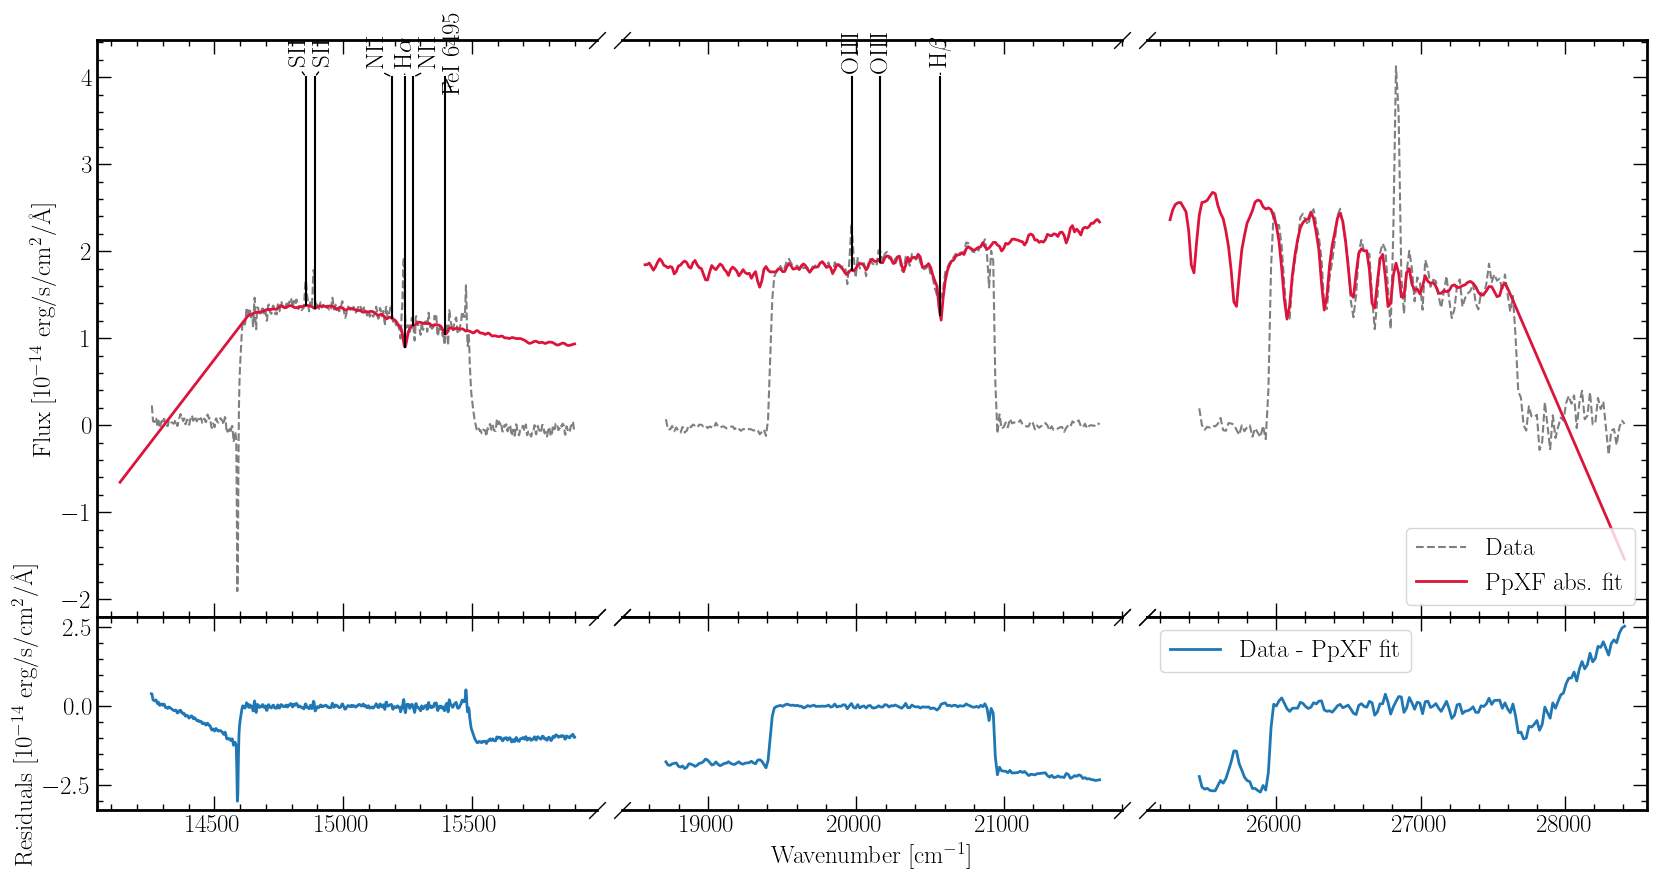

In [102]:

# Undersamples the ppxf best fit spectrum (including emission lines) and the best fit absorption 
# spectrum and cuts them to the de-redshifted SITELLE filters (SN1, SN2 and SN3)
#bestfit_sn1, abs_bestfit_sn1 = undersampling_interp(pp, wavenb_sn1_crop)
#bestfit_sn2, abs_bestfit_sn2 = undersampling_interp(pp, wavenb_sn2_crop)
#bestfit_sn3, abs_bestfit_sn3 = undersampling_interp(pp, wavenb_sn3_crop)
bestfit_sn1, abs_bestfit_sn1 = undersampling_interp(pp, wavenb_sn1)
bestfit_sn2, abs_bestfit_sn2 = undersampling_interp(pp, wavenb_sn2)
bestfit_sn3, abs_bestfit_sn3 = undersampling_interp(pp, wavenb_sn3)


# Undersampled ppxf best-fit 
bestfit = [norm_factor*bestfit_sn1, norm_factor*bestfit_sn2, norm_factor*bestfit_sn3]

# Undersampled ppxf absorption best-fit
abs_bestfit = [norm_factor*abs_bestfit_sn1, norm_factor*abs_bestfit_sn2, norm_factor*abs_bestfit_sn3 ]

# Copy of the original absorption spectrum
#wavenb_copy   = [wavenb_sn1_crop, wavenb_sn2_crop, wavenb_sn3_crop]
#spectra_copy  = [flux_sn1_crop,   flux_sn2_crop,   flux_sn3_crop]
#
#plot_abs_spectrum_ppxf(wavenb_copy, spectra_copy, bestfit, abs_bestfit)

wavenb_copy   = [wavenb_sn1, wavenb_sn2, wavenb_sn3]
spectra_copy  = [flux_sn1,   flux_sn2,   flux_sn3]

titfig=''
plot_abs_spectrum_ppxf(wavenb_copy, spectra_copy, bestfit, abs_bestfit,titfig)

In [103]:
for i in range(len(wavenb_sn1)):
    if (wavenb_sn1[i] >26000) & (wavenb_sn1[i] < 26010) : 
        print(i,wavenb_sn1[i-1],wavenb_sn1[i-1],wavenb_sn1[i+1])
    if (wavenb_sn1[i] >27700) & (wavenb_sn1[i] < 27720) : 
        print(i,wavenb_sn1[i-1],wavenb_sn1[i-1],wavenb_sn1[i+1])
for i in range(len(wavenb_sn2)):
    if (wavenb_sn2[i] >19400) & (wavenb_sn2[i] < 19410) : 
        print(i,wavenb_sn2[i-1],wavenb_sn2[i-1],wavenb_sn2[i+1])
    if (wavenb_sn2[i] >20900) & (wavenb_sn2[i] < 20920) : 
        print(i,wavenb_sn2[i-1],wavenb_sn2[i-1],wavenb_sn2[i+1])
for i in range(len(wavenb_sn3)):
    if (wavenb_sn3[i] >14660) & (wavenb_sn3[i] < 14662) : 
        print(i,wavenb_sn3[i-1],wavenb_sn3[i-1],wavenb_sn3[i+1])
    if (wavenb_sn3[i] >15490) & (wavenb_sn3[i] < 15495) : 
        print(i,wavenb_sn3[i-1],wavenb_sn3[i-1],wavenb_sn3[i+1])

print(wavenb_sn1[40] ,wavenb_sn1[125])
print(wavenb_sn2[70 ],wavenb_sn2[163])
print(wavenb_sn3[245],wavenb_sn3[632])

40 25984.2509867955 25984.2509867955 26020.97784331943
133 27692.0498149018 27692.0498149018 27728.776671415133
59 19389.844201625936 19389.844201625936 19418.10928064389
165 20887.8933892231 20887.8933892231 20916.158468223824
166 20902.025928728493 20902.025928728493 20930.291007729265
251 14658.64351351004 14658.64351351004 14662.840090524594
647 15489.565762489512 15489.565762489512 15493.762339502584
648 15491.66405099626 15491.66405099626 15495.860628009006
26002.614415051008 27563.50581709228
19559.434675693632 20873.760849713915
14648.152070971548 15460.189723381229


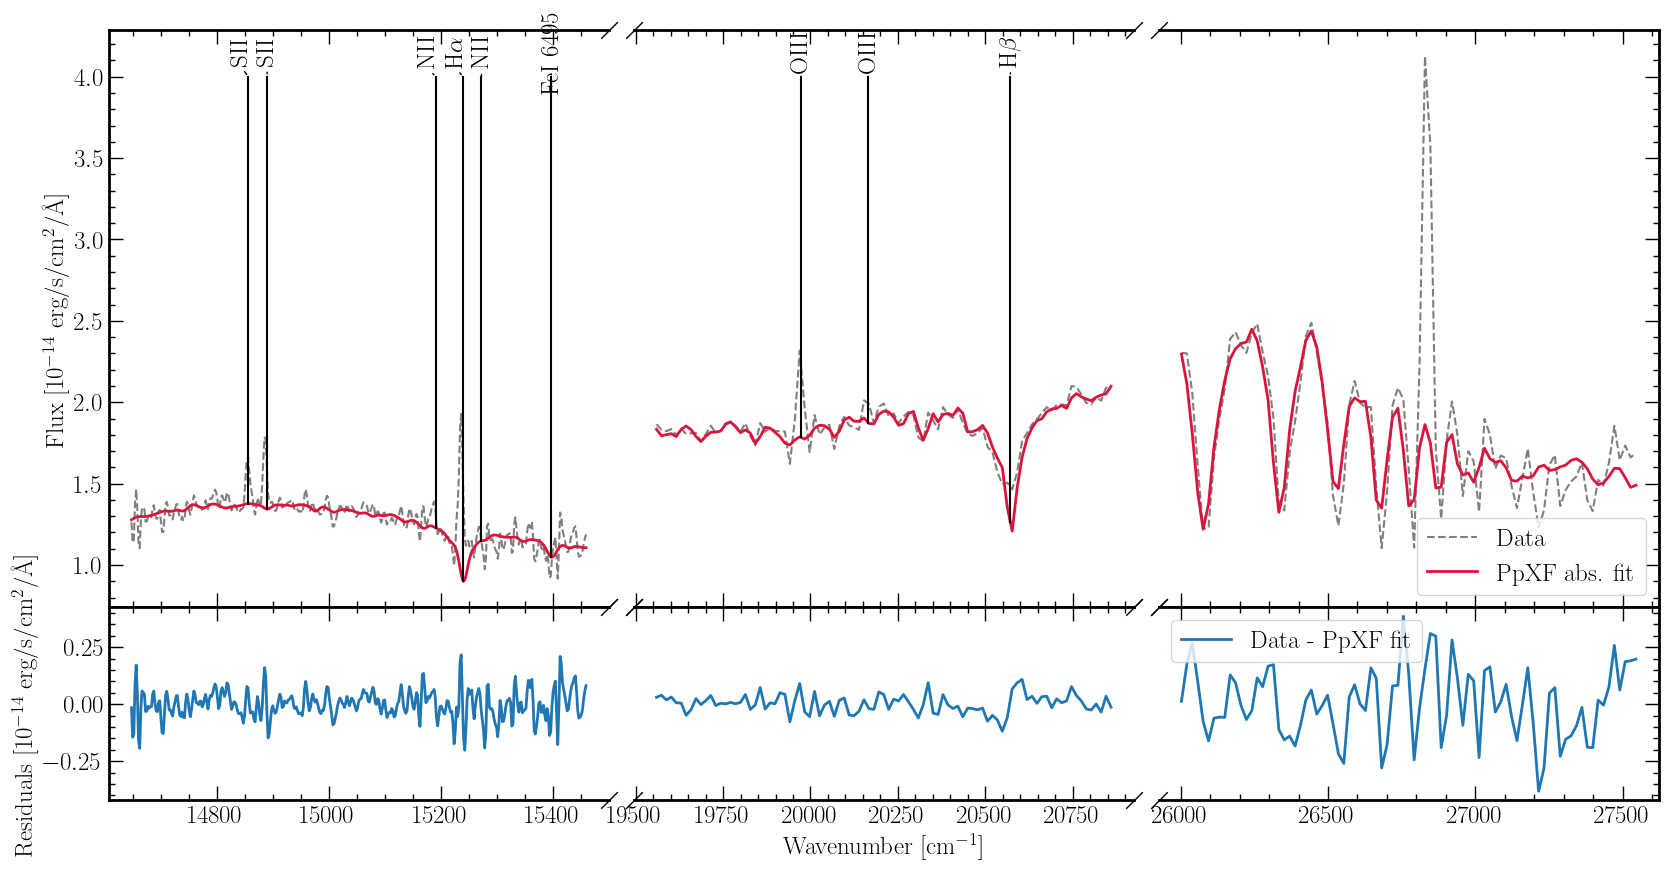

In [104]:
wavenb_sn1_crop = wavenb_sn1[40:125]
wavenb_sn2_crop = wavenb_sn2[70:163]
wavenb_sn3_crop = wavenb_sn3[245:632]

flux_sn1_crop = flux_sn1[40:125]
flux_sn2_crop = flux_sn2[70:163]
flux_sn3_crop = flux_sn3[245:632]

# Undersamples the ppxf best fit spectrum (including emission lines) and the best fit absorption 
# spectrum and cuts them to the de-redshifted SITELLE filters (SN1, SN2 and SN3)
bestfit_sn1, abs_bestfit_sn1 = undersampling_interp(pp, wavenb_sn1_crop)
bestfit_sn2, abs_bestfit_sn2 = undersampling_interp(pp, wavenb_sn2_crop)
bestfit_sn3, abs_bestfit_sn3 = undersampling_interp(pp, wavenb_sn3_crop)


# Undersampled ppxf best-fit 
bestfit = [norm_factor*bestfit_sn1, norm_factor*bestfit_sn2, norm_factor*bestfit_sn3]

# Undersampled ppxf absorption best-fit
abs_bestfit = [norm_factor*abs_bestfit_sn1, norm_factor*abs_bestfit_sn2, norm_factor*abs_bestfit_sn3 ]

# Copy of the original absorption spectrum
wavenb_copy   = [wavenb_sn1_crop, wavenb_sn2_crop, wavenb_sn3_crop]
spectra_copy  = [flux_sn1_crop,   flux_sn2_crop,   flux_sn3_crop]
#
titfig='2-PPXF_model_zoom_'+tit+'.jpeg'
plot_abs_spectrum_ppxf(wavenb_copy, spectra_copy, bestfit, abs_bestfit,titfig)



# **5. Saving absorption spectrum**

In [105]:
# Saving the whole spectrum from ppxf as a text file - median at redshift 0

savefile='no'  # 23 nov 25
if savefile == 'yes':
    abs_bestfit_ppxf = np.array([np.flip(1e8 / pp.lam), np.flip(pp.bestfit - pp.gas_bestfit)]).T
    header_file = "This file contains the best-fit absorption spectrum obtained from PPXF \n Wavenumber (cm-1) \t Relative flux"
    np.savetxt(Folder+'3-PPXF_model_'+tit+'.txt', abs_bestfit_ppxf, header=header_file)



11813


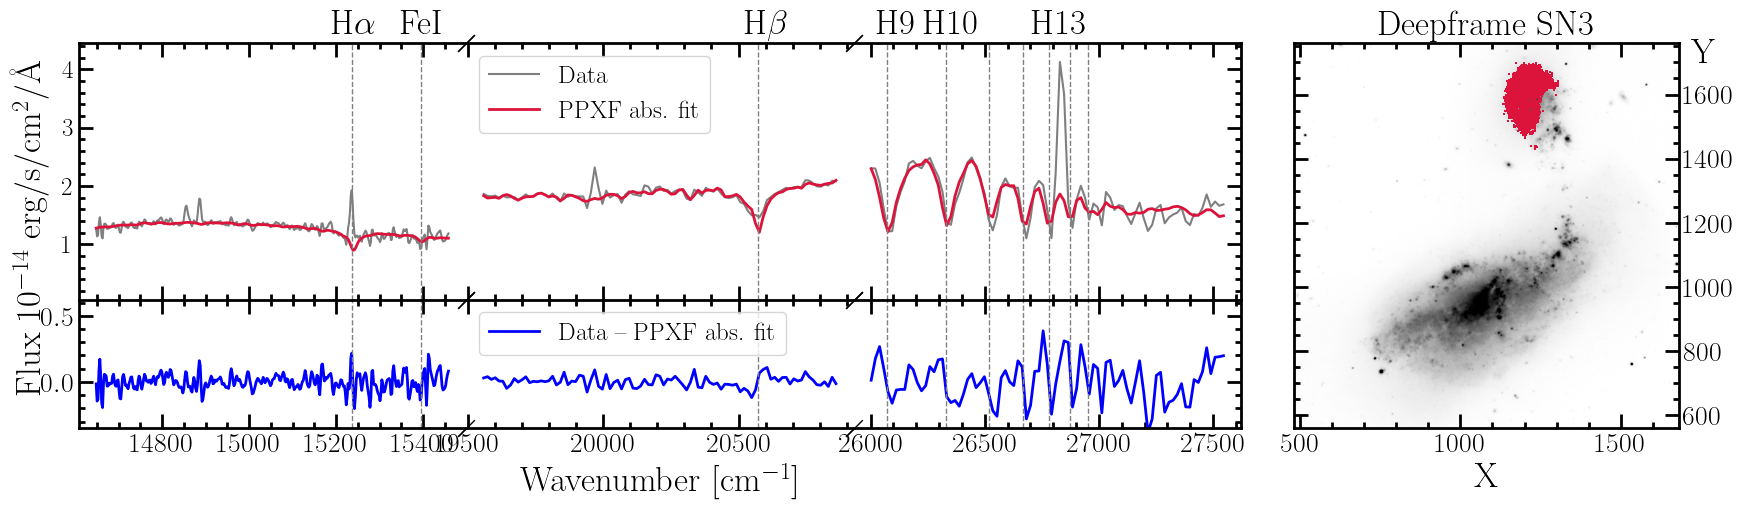

In [106]:

## CR2

def plot_px2use2(ax):
    """ 
    Shows the pixels used to create the absorption spectra 
    
    params:
        ax (Axes): Subplot in a figure
    """
    # Plots deepframes
    ax.imshow(np.log10(deepframe_sn3), origin='lower', cmap='Grays', 
        vmin=np.nanpercentile(np.log10(deepframe_sn3), 10), 
        vmax=np.nanpercentile(np.log10(deepframe_sn3), 99.9))

    # Plots on top on the deep pixels (in red) used to create the absorption spectra 
    y, x = np.where(px2use)
    ax.scatter(x, y, s=1, linewidth=0, color="crimson", marker="s")
    
    # Crop
    dely = 200 
    cutedg = -100
    ax.set_xlim(xc - radius_mask - cutedg, xc + radius_mask + cutedg)
    ax.set_ylim(yc+dely - radius_mask - cutedg, yc+dely + radius_mask + cutedg)
    
    # x and y axes labels
    ax.set_xlabel('X',size=25)
    #ax.set_ylabel('Y')
    plt.text(1720,1700,'Y',size=25) #730,1000,'Y')
    #ax.set_ylabel(f'Y',loc='right')
    #yaxis.labellocation(right)
    print(np.count_nonzero(px2use))
    #ax.set_title(f'Deepframe SN3')
    ax.set_title(f'Deepframe SN3',size=25) # \n Nb. px. used (in red): {np.count_nonzero(px2use)}')
    return


#wavenb_copy   = [wavenb_sn1_crop, wavenb_sn2_crop, wavenb_sn3_crop]
#spectra_copy  = [flux_sn1_crop,   flux_sn2_crop,   flux_sn3_crop]
wav          = [wavenb_sn1_crop, wavenb_sn2_crop, wavenb_sn3_crop]
spec         = [flux_sn1_crop,   flux_sn2_crop,   flux_sn3_crop]
spec_absfit  = [np.copy(abs_bestfit[0]), np.copy(abs_bestfit[1]), np.copy(abs_bestfit[2])]
residu       = [np.copy(flux_sn1_crop-bestfit[0]), 
                np.copy(flux_sn2_crop-bestfit[1]), 
                np.copy(flux_sn3_crop-bestfit[2])]

# Exponant of a power of 10
exp = int(np.floor(np.log10(np.nanmax(flux_sn3_crop))))


# Multiply by 10^exp to get rid of scientific notation on the top of the plot
for i in range(len(spec)):
    spec[i]        = spec[i]*10**-exp
    spec_absfit[i] = abs_bestfit[i]*10**-exp
    residu[i]      = residu[i]*10**-exp

y1 = np.nanmin(np.concatenate(spec))
y2 = np.nanmax(np.concatenate(spec))
dely = (y2-y1)/10
ylim1 = 0.05 #y1-dely
ylim2 = y2+dely
ylim1r = -0.35
ylim2r = 0.62

# ... 
fig = plt.figure(figsize=(20, 10)) #, constrained_layout=True)
plt.subplots_adjust(wspace = 0,hspace=0) 


# Axes of the figure
ax1 = plt.subplot2grid(shape=(6,8), loc=(0, 0), colspan=2, rowspan=2)
ax2 = plt.subplot2grid(shape=(6,8), loc=(0, 2), colspan=2, rowspan=2, sharey=ax1)
ax3 = plt.subplot2grid(shape=(6,8), loc=(0, 4), colspan=2, rowspan=2, sharey=ax1)
ax4 = plt.subplot2grid(shape=(6,8), loc=(2, 0), colspan=2, rowspan=1, sharex=ax1)
ax5 = plt.subplot2grid(shape=(6,8), loc=(2, 2), colspan=2, rowspan=1, sharex=ax2, sharey=ax4)
ax6 = plt.subplot2grid(shape=(6,8), loc=(2, 4), colspan=2, rowspan=1, sharex=ax3, sharey=ax4)
ax7 = plt.subplot2grid(shape=(6,8), loc=(1, 6), colspan=2, rowspan=2)

    
# ... 
axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7]
for ax in axes:
    # Ticks parameter
    ax.tick_params('both', which = 'both', direction='in', length=10, width=2, top=True, right=True)
    ax.tick_params('both', which = 'both', direction='in', length=10, width=2, top=True, right=True)
    ax.tick_params('both', which = 'minor', length=4)
    ax.tick_params('both', which = 'minor', length=4)
    ## Shows minor thicks
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

for ax in [ax1, ax2, ax3]:
    ax.set_ylim(ylim1,ylim2)
for ax in [ax4, ax5, ax6]:
    ax.set_ylim(ylim1r,ylim2r)

# Hides y-axis ticks 
ax1.spines['right'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax1.tick_params(axis='both', which = 'both', right=False, labelbottom=False)
ax2.tick_params(axis='both', which = 'both', labelleft=False, left=False, right=False, labelbottom=False)
ax3.tick_params(axis='both', which = 'both', labelleft=False, left=False,labelbottom=False)  
    
ax4.spines['right'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax6.spines['left'].set_visible(False)
ax4.tick_params(axis='both', which = 'both', right=False, labelsize=20) 
ax5.tick_params(axis='both', which = 'both', labelleft=False, left=False, right=False,labelsize=20)
ax6.tick_params(axis='both', which = 'both', labelleft=False, left=False,labelsize=20)  
ax7.tick_params(axis='both', which = 'both', labelright=True, labelleft=False, labelsize=20) 

# Hides x-axis ticks 
ax1.spines['bottom'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
          
# Plots abs spectrum 
ax3.plot(wav[0], spec[0], linestyle='-', c='tab:gray', label='Data')
ax2.plot(wav[1], spec[1], linestyle='-', c='tab:gray', label='Data')
ax1.plot(wav[2], spec[2], linestyle='-', c='tab:gray', label='Data')
# Plot pPXF abs spectrum
ax3.plot(wav[0], spec_absfit[0], linestyle='-', linewidth=2, c='crimson', label='PPXF abs. fit')
ax2.plot(wav[1], spec_absfit[1], linestyle='-', linewidth=2, c='crimson', label='PPXF abs. fit')
ax1.plot(wav[2], spec_absfit[2], linestyle='-', linewidth=2, c='crimson', label='PPXF abs. fit')
# Plots res spectrum     
ax6.plot(wav[0], residu[0], linestyle='-', linewidth=2, c='blue', label='Data -- PPXF abs. fit')
ax5.plot(wav[1], residu[1], linestyle='-', linewidth=2, c='blue', label='Data -- PPXF abs. fit')
ax4.plot(wav[2], residu[2], linestyle='-', linewidth=2, c='blue', label='Data -- PPXF abs. fit')


plot_broken_axis(axes[3:])
plot_broken_axis(axes[:3])

# Shows the pixels used to create the absorption spectra
pos1 = ax1.get_position()  # Haut gauche
pos3 = ax3.get_position()  # Haut du dernier spectre à droite
pos6 = ax6.get_position()  # Bas du dernier spectre

# Hauteur totale des spectres
fig_height = pos1.y1 - pos6.y0

# Taille (largeur = hauteur) du carré
new_size = fig_height

# Position du carré à droite de ax3
x0 = pos3.x1 - 0.07  # petit espace entre ax3 et ax7
y0 = pos6.y0         # alignement bas sur les spectres

# Si ça dépasse la figure, on ajuste un peu
if y0 + new_size > 1:
    new_size = 1 - y0 - 0.02  # marge de sécurité

# Mise à jour de la position de ax7 (format [x0, y0, largeur, hauteur])
ax7.set_position([x0, y0, new_size, new_size])
plot_px2use2(ax7)


# x and y axes labels of the spectra plot
ax5.set_xlabel(f'Wavenumber [cm$^{{-1}}$]',size=25)
ax4.text(14450,-0.04,rf'Flux 10$^{{{exp}}}$ erg/s/cm$^{2}$/\AA',rotation=90,size=25)
#ax4.set_ylabel(f'Flux 10$^{{{exp}}}$ erg/s/cm$^{2}$/$\AA$')
#ax2.set_title('Continuum spectra \n')

xxx, name = 1e8/6562.80, r'H$\alpha$'
ax1.text(xxx-50,ylim2+dely/2,name,size=25)
ax1.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax4.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')
xxx, name = 15396, 'FeI'
ax1.text(xxx-50,ylim2+dely/2,name,size=25)
ax1.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax4.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')
xxx, name = 1e8/4861.33, r'H$\beta$'
ax2.text(xxx-50,ylim2+dely/2,name,size=25)
ax2.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax5.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')

xxx,name = 1e8/3835.39, r'H9'
ax3.text(xxx-50,ylim2+dely/2,name,size=25)
ax3.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax6.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')
xxx, name = 1e8/3798, r'H10'
ax3.text(xxx-100,ylim2+dely/2,name,size=25)
ax3.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax6.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')
xxx, name = 1e8/3771, r'H11'
#ax3.text(xxx-80,ylim2+dely/2,name,size=25)
ax3.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax6.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')
xxx, name = 1e8/3750, r'H12'
#ax3.text(xxx-50,ylim2+dely/2,name)
ax3.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax6.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')
xxx, name = 1e8/3734, r'H13'
ax3.text(xxx-80,ylim2+dely/2,name,size=25)
ax3.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax6.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')
xxx, name = 1e8/3721, r'H14'
#ax3.text(xxx-90,ylim2+dely/2,name,size=25)
ax3.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax6.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')
xxx, name = 1e8/3710, r'H15'
#ax3.text(xxx-90,ylim2+dely/2,name,size=25)
ax3.plot([xxx,xxx],[ylim1,ylim2],  linestyle='--', linewidth=1, color='gray')
ax6.plot([xxx,xxx],[ylim1r,ylim2r],linestyle='--', linewidth=1, color='gray')


# Legend
ax2.legend(loc='upper left')
ax5.legend(loc='upper left')

fig.savefig(Folder+'3-PPXF_model_'+tit+'.pdf',bbox_inches = 'tight')
plt.show()
    
fig.clf()
plt.close(fig)



    

## Normalization

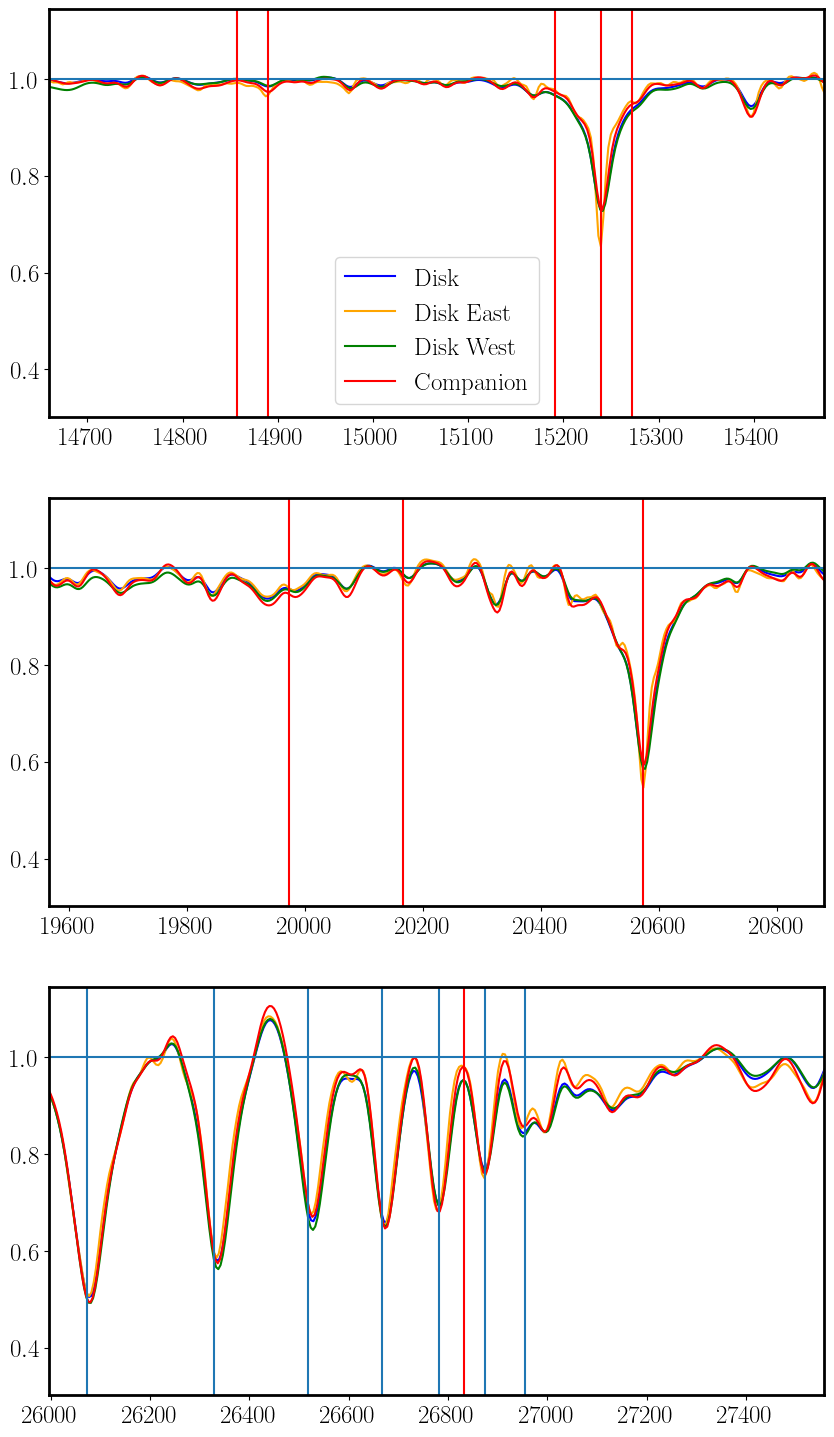

In [112]:
from pybaselines import Baseline

fitord=13


file ='3-Absorption_results_Wfin/3-PPXF_model_Disk_SNR5_Ha5e-18_vobs.txt'
abs_spec      = np.loadtxt(file).T
abs_wn_disk   = abs_spec[0]
baseline_fitter   = Baseline(x_data=abs_spec[0])
abs_fit           = baseline_fitter.quant_reg(abs_spec[1], poly_order=fitord,quantile=0.9 )[0]
abs_spec_disk_nor = np.copy(abs_spec)
abs_spec_disk_nor[1] = (abs_spec[1])/abs_fit

file ='3-Absorption_results_Wfin/3-PPXF_model_Disk_e_SNR5_Ha5e-18_vobs.txt'
abs_spec       = np.loadtxt(file).T
abs_wn_diske   = abs_spec[0]
baseline_fitter    = Baseline(x_data=abs_spec[0])
abs_fit            = baseline_fitter.quant_reg(abs_spec[1], poly_order=fitord,quantile=0.9 )[0]
abs_spec_diske_nor = np.copy(abs_spec)
abs_spec_diske_nor[1] = (abs_spec[1])/abs_fit

file ='3-Absorption_results_Wfin/3-PPXF_model_Disk_w_SNR5_Ha5e-18_vobs.txt'
abs_spec       = np.loadtxt(file).T
abs_wn_diskw   = abs_spec[0]
baseline_fitter    = Baseline(x_data=abs_spec[0])
abs_fit            = baseline_fitter.quant_reg(abs_spec[1], poly_order=fitord,quantile=0.9 )[0]
abs_spec_diskw_nor = np.copy(abs_spec)
abs_spec_diskw_nor[1] = (abs_spec[1])/abs_fit
#
file ='3-Absorption_results_Wfin/3-PPXF_model_Com_SNR5_Ha5e-18_vobs_m50m50m50.txt' 
abs_spec       = np.loadtxt(file).T
abs_wn_com     = abs_spec[0]
baseline_fitter    = Baseline(x_data=abs_spec[0])
abs_fit            = baseline_fitter.quant_reg(abs_spec[1], poly_order=fitord,quantile=0.9 )[0]
abs_spec_com_nor   = np.copy(abs_spec)
abs_spec_com_nor[1] = (abs_spec[1])/abs_fit


wline0    = 1.e8 / emi_lines 

nyy, nxx, ip = 3,1, 0
fig = plt.figure(figsize=(10*nxx,6*nyy))
fig.subplots_adjust(hspace=0.2,wspace=0.1)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
plt.xlim(14660,15474)
plt.plot(abs_wn_disk, abs_spec_disk_nor[1] ,color='blue',   label='Disk')
plt.plot(abs_wn_diske,abs_spec_diske_nor[1],color='orange', label='Disk East')
plt.plot(abs_wn_diskw,abs_spec_diskw_nor[1],color='green',  label='Disk West')
plt.plot(abs_wn_com,  abs_spec_com_nor[1],  color='red',    label='Companion')
plt.axhline(y=1)
for i in range(0,9):
    plt.axvline(x=wline0[i],color='red')
plt.legend()

    
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
plt.xlim(19566,20880)
plt.plot(abs_wn_disk, abs_spec_disk_nor[1] ,color='blue',   label='Disk')
plt.plot(abs_wn_diske,abs_spec_diske_nor[1],color='orange', label='Disk East')
plt.plot(abs_wn_diskw,abs_spec_diskw_nor[1],color='green',  label='Disk West')
plt.plot(abs_wn_com,  abs_spec_com_nor[1],  color='red',    label='Companion')
plt.axhline(y=1)
for i in range(0,9):
    plt.axvline(x=wline0[i],color='red')
    
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
plt.xlim(25997,27558)
plt.plot(abs_wn_disk, abs_spec_disk_nor[1] ,color='blue',   label='Disk')
plt.plot(abs_wn_diske,abs_spec_diske_nor[1],color='orange', label='Disk East')
plt.plot(abs_wn_diskw,abs_spec_diskw_nor[1],color='green',  label='Disk West')
plt.plot(abs_wn_com,  abs_spec_com_nor[1],  color='red',    label='Companion')
plt.axhline(y=1)
for i in range(0,9):
    plt.axvline(x=wline0[i],color='red')
plt.axvline(x=1e8/3835.39) #H9
plt.axvline(x=1e8/3798) #H10
plt.axvline(x=1e8/3771) #H11
plt.axvline(x=1e8/3750) #H12
plt.axvline(x=1e8/3734) #H13
plt.axvline(x=1e8/3721) #H14
plt.axvline(x=1e8/3710) #H15
#plt.axvline(x=1e8/3701) #H16

    
fig.savefig(Folder+'4-Model_compare_norm1309_all.jpeg',bbox_inches = 'tight')
#plt.show()

## Saving normalized spectrum


In [113]:
savefile='no'  # 23 nov 25

if savefile == 'yes':
    fitord=13
    header_file     = "Absorption spectrum obtained from PPXF with vobs \n Wavenumber (cm-1) \t Relative flux mormalized"

    filein  = Folder+'3-PPXF_model_Disk_SNR5_Ha5e-18_vobs.txt' 
    fileout = Folder+'3-PPXF_model_norm_Disk_SNR5_Ha5e-18_fin.txt' 
    abs_spec        = np.loadtxt(filein).T
    abs_wn          = abs_spec[0]
    baseline_fitter = Baseline(x_data=abs_spec[0])
    abs_fit         = baseline_fitter.quant_reg(abs_spec[1], poly_order=fitord,quantile=0.9 )[0]
    abs_spec_nor    = np.copy(abs_spec)
    abs_spec_nor[1] = (abs_spec[1])/abs_fit
    abs_spec_nor    = np.array([abs_wn, abs_spec_nor[1]]).T    
    np.savetxt(fileout, abs_spec_nor, header=header_file)
    print(fileout)

    filein  = Folder+'3-PPXF_model_Disk_e_SNR5_Ha5e-18_vobs.txt' 
    fileout = Folder+'3-PPXF_model_norm_DiskE_SNR5_Ha5e-18_fin.txt'     
    abs_spec        = np.loadtxt(filein).T
    abs_wn          = abs_spec[0]
    baseline_fitter = Baseline(x_data=abs_spec[0])
    abs_fit         = baseline_fitter.quant_reg(abs_spec[1], poly_order=fitord,quantile=0.9 )[0]
    abs_spec_nor    = np.copy(abs_spec)
    abs_spec_nor[1] = (abs_spec[1])/abs_fit
    abs_spec_nor    = np.array([abs_wn, abs_spec_nor[1]]).T    
    np.savetxt(fileout, abs_spec_nor, header=header_file)
    print(fileout)

    filein  = Folder+'3-PPXF_model_Disk_w_SNR5_Ha5e-18_vobs.txt' 
    fileout = Folder+'3-PPXF_model_norm_DiskW_SNR5_Ha5e-18_fin.txt' 
    abs_spec        = np.loadtxt(filein).T
    abs_wn          = abs_spec[0]
    baseline_fitter = Baseline(x_data=abs_spec[0])
    abs_fit         = baseline_fitter.quant_reg(abs_spec[1], poly_order=fitord,quantile=0.9 )[0]
    abs_spec_nor    = np.copy(abs_spec)
    abs_spec_nor[1] = (abs_spec[1])/abs_fit
    abs_spec_nor    = np.array([abs_wn, abs_spec_nor[1]]).T    
    np.savetxt(fileout, abs_spec_nor, header=header_file)
    print(fileout)

    filein  = Folder+'3-PPXF_model_Com_SNR5_Ha5e-18_vobs_m50m50m50.txt' 
    fileout = Folder+'3-PPXF_model_norm_Com_SNR5_Ha5e-18_fin.txt'     
    abs_spec        = np.loadtxt(filein).T
    abs_wn          = abs_spec[0]
    baseline_fitter = Baseline(x_data=abs_spec[0])
    abs_fit         = baseline_fitter.quant_reg(abs_spec[1], poly_order=fitord,quantile=0.9 )[0]
    abs_spec_nor    = np.copy(abs_spec)
    abs_spec_nor[1] = (abs_spec[1])/abs_fit
    abs_spec_nor    = np.array([abs_wn, abs_spec_nor[1]]).T    
    np.savetxt(fileout, abs_spec_nor, header=header_file)
    print(fileout)



3-Absorption_results_Wfin/3-PPXF_model_norm_Disk_SNR5_Ha5e-18_fin.txt
3-Absorption_results_Wfin/3-PPXF_model_norm_DiskE_SNR5_Ha5e-18_fin.txt
3-Absorption_results_Wfin/3-PPXF_model_norm_DiskW_SNR5_Ha5e-18_fin.txt
3-Absorption_results_Wfin/3-PPXF_model_norm_Com_SNR5_Ha5e-18_fin.txt
